## Section 1: Imports and Device Configuration


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib
import copy
import os
import time

# Random seed fixed so all results are reproducible.
SEED = 42
torch.manual_seed(SEED)

# Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"GPU name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")

# Image resolution
IMG_SIZE = 256

Using device: cuda
GPU name: Tesla T4


In [2]:
# Project setup for reproducible execution from the public GitHub repository.

import os
import subprocess

REPO_URL = "https://github.com/nicolecodes23/CM3070-Neural-Style-Transfer.git"

REPO_NAME = "CM3070-Neural-Style-Transfer"

#clone the public repository so that all required input images are available.
REPO_DIR = os.path.join('/content', REPO_NAME)

if not os.path.exists(os.path.join(REPO_DIR, '.git')):
    print("Cloning project repository")
    subprocess.run(
        ['git', 'clone', '--depth', '1', REPO_URL, REPO_DIR],
        check=True
    )
else:
    print("Repository already present in this runtime.")

# Project paths
PROJECT_DIR = REPO_DIR
INPUT_DIR   = os.path.join(REPO_DIR, 'inputs')
OUTPUT_DIR  = os.path.join(REPO_DIR, 'outputs')

os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Project folder: {PROJECT_DIR}")
print(f"Input folder:   {INPUT_DIR}")
print(f"Output folder:  {OUTPUT_DIR}")

Cloning project repository
Project folder: /content/CM3070-Neural-Style-Transfer
Input folder:   /content/CM3070-Neural-Style-Transfer/inputs
Output folder:  /content/CM3070-Neural-Style-Transfer/outputs


## Section 2: Image Loading and Preprocessing

In [5]:
# Central image registry.
# All required source images are stored in the public GitHub repository under the inputs/ directory.

content_images = {
    'cityscape': os.path.join(INPUT_DIR, 'content.jpg'),
    'portrait':  os.path.join(INPUT_DIR, 'portrait.jpg'),
    'landscape': os.path.join(INPUT_DIR, 'landscape.jpg'),
}
style_images = {
    'starry_night': os.path.join(INPUT_DIR, 'style.jpg'),
    'chinese_ink':  os.path.join(INPUT_DIR, 'ink-style.jpg'),
    'op_art':       os.path.join(INPUT_DIR, 'op_art.jpg'),
    'pop_art':      os.path.join(INPUT_DIR, 'pop_art.jpg'),
}

# Confirm that every required image is available before continuing.
all_paths = {**content_images, **style_images}

for name, path in all_paths.items():
    assert os.path.exists(path), f"Missing image: {name} -> {path}"
    print(f"  [FOUND] {name:<14} {path}")

print("\nAll 7 required source images confirmed.")

  [FOUND] cityscape      /content/CM3070-Neural-Style-Transfer/inputs/content.jpg
  [FOUND] portrait       /content/CM3070-Neural-Style-Transfer/inputs/portrait.jpg
  [FOUND] landscape      /content/CM3070-Neural-Style-Transfer/inputs/landscape.jpg
  [FOUND] starry_night   /content/CM3070-Neural-Style-Transfer/inputs/style.jpg
  [FOUND] chinese_ink    /content/CM3070-Neural-Style-Transfer/inputs/ink-style.jpg
  [FOUND] op_art         /content/CM3070-Neural-Style-Transfer/inputs/op_art.jpg
  [FOUND] pop_art        /content/CM3070-Neural-Style-Transfer/inputs/pop_art.jpg

All 7 required source images confirmed.


In [4]:
# Image Preprocessing
# VGG19 was trained on ImageNet images normalised with these exact values.
# Every image passed through VGG19 must use the same normalisation or the feature maps will not reflect what the network actually learned.

IMAGENET_MEAN = [0.485, 0.456, 0.406]   # RGB channel means
IMAGENET_STD  = [0.229, 0.224, 0.225]   # RGB channel stds

# Build the reusable preprocessing pipeline
preprocess = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

def load_image(path, device):
    """
    Load a single image from disk, preprocess it for VGG19, and move it to the target device as a 4-dimensional tensor (batch dimension included).

    VGG19 expects input shape [batch, channels, height, width]. We add a batch dimension of 1 using .unsqueeze(0) because our batch size is always
    """
    image = Image.open(path).convert('RGB')
    tensor = preprocess(image)
    tensor = tensor.unsqueeze(0)
    return tensor.to(device)

In [6]:
# Load every image once into the central tensor dictionaries.
content_tensors = {name: load_image(path, device)
                   for name, path in content_images.items()}
style_tensors   = {name: load_image(path, device)
                   for name, path in style_images.items()}

# Baseline single-pair aliases.
content_tensor = content_tensors['cityscape']
style_tensor   = style_tensors['starry_night']

print("Content images loaded:")
for name, t in content_tensors.items():
    print(f"  {name:<10} {tuple(t.shape)}")
print("Style images loaded:")
for name, t in style_tensors.items():
    print(f"  {name:<12} {tuple(t.shape)}")
print(f"\nBaseline pair --> content='cityscape', style='starry_night'")
print(f"  content tensor {tuple(content_tensor.shape)}| "
      f"range [{content_tensor.min():.3f}, {content_tensor.max():.3f}]|{content_tensor.device}")

Content images loaded:
  cityscape  (1, 3, 256, 256)
  portrait   (1, 3, 256, 256)
  landscape  (1, 3, 256, 256)
Style images loaded:
  starry_night (1, 3, 256, 256)
  chinese_ink  (1, 3, 256, 256)
  op_art       (1, 3, 256, 256)
  pop_art      (1, 3, 256, 256)

Baseline pair --> content='cityscape', style='starry_night'
  content tensor (1, 3, 256, 256)| range [-2.101, 2.222]|cuda:0


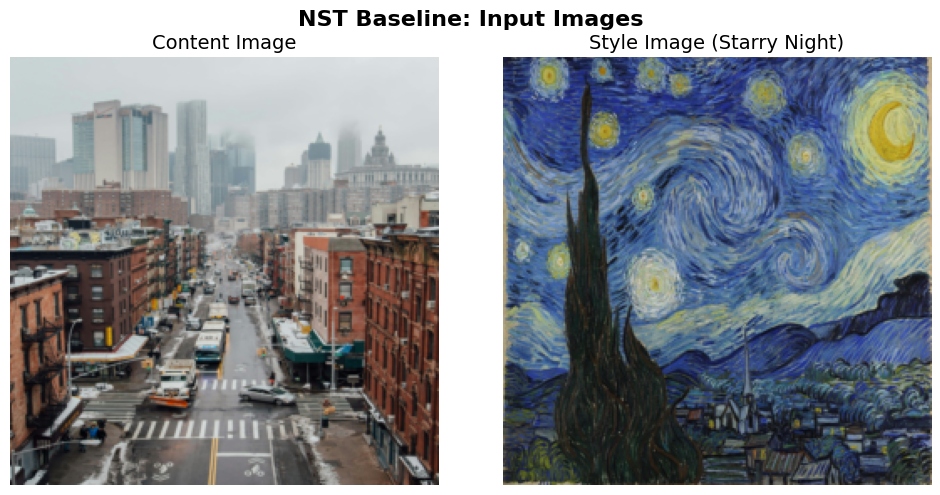

In [7]:
# Visualise both input images by denormalising before displaying.
def tensor_to_image(tensor):
    """
    Convert a normalised VGG19-format tensor back to a displayable numpy array. Reverses the ImageNet normalisation applied during preprocessing so the
    image can be displayed with matplotlib. Clips to [0,1] to handle any minor floating-point overshot.
    """
    image = tensor.clone().detach()
    image = image.squeeze(0)
    image = image.cpu()

    # Reverse the normalisation where pixel = (normalised x std) + mean
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    image = image * std + mean

    image = image.permute(1, 2, 0)
    image = image.clamp(0, 1)
    return image.numpy()

# Display content and style images
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(tensor_to_image(content_tensor))
axes[0].set_title('Content Image', fontsize=14)
axes[0].axis('off')

axes[1].imshow(tensor_to_image(style_tensor))
axes[1].set_title('Style Image (Starry Night)', fontsize=14)
axes[1].axis('off')

plt.suptitle('NST Baseline: Input Images', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'input_images.png'), dpi=150, bbox_inches='tight')
plt.show()

## Section 3: VGG19 Model loading and Layer Selection

In [ ]:
# VGG19 Model Loading
from torchvision.models import vgg19, VGG19_Weights

def load_vgg19(device):
    """
    Load a pretrained VGG19 network for use as a fixed feature extractor. The model is used only to read out intermediate feature maps. It is not trained.
    All parameters are frozen, and keep only the convolutional features block.
    """
    # Load VGG19 with ImageNet-pretrained weights
    weights = VGG19_Weights.DEFAULT
    model = vgg19(weights=weights).features

    # Freeze every parameter as VGG19 acts as a measuring instrument, not a model to train.
    for param in model.parameters():
        param.requires_grad = False

    # disables training-specific behaviour
    model = model.to(device).eval()

    return model

# Build the feature extractor
vgg = load_vgg19(device)
print("VGG19 ready and set to eval mode.")
print(f"Number of layers in vgg.features: {len(vgg)}")

VGG19 ready and set to eval mode.
Number of layers in vgg.features: 37


In [ ]:
# PyTorch index mapping

CONTENT_LAYER = {'block5_conv2': 30}

# Style layers with one conv layer per block, spanning shallow→deep, capturing texture at five scales of abstraction.
STYLE_LAYERS = {
    'block1_conv1': 0,
    'block2_conv1': 5,
    'block3_conv1': 10,
    'block4_conv1': 19,
    'block5_conv1': 28,
}

# print the actual PyTorch module sitting at each index to confirm Conv2d layers in the right positions.
print("Content layer:")
for name, idx in CONTENT_LAYER.items():
    print(f"  [{idx:>2}] {name:<14} -> {vgg[idx]}")

print("Style layers:")
for name, idx in STYLE_LAYERS.items():
    print(f"  [{idx:>2}] {name:<14} -> {vgg[idx]}")

Content layer:
  [30] block5_conv2   -> Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Style layers:
  [ 0] block1_conv1   -> Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  [ 5] block2_conv1   -> Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  [10] block3_conv1   -> Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  [19] block4_conv1   -> Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  [28] block5_conv1   -> Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))


## Section 4: Loss Functions(Content loss, Gram Matrix, Style loss)

In [ ]:
def get_features(image, model, layer_indices):
    """
    Pass an image through VGG19 and extract feature maps at specified layers.
    """
    features = {}
    x = image  # start with the input image

    # Walk through every layer in order, feeding the output of one layer into the next. enumerate gives us the index of each layer
    for index, layer in enumerate(model):
        x = layer(x)

        # save a copy of the output.
        if index in layer_indices:
            features[index] = x

    return features

In [ ]:
def gram_matrix(feature_map):
    """
    Compute the Gram matrix of a feature map for style representation.

    The Gram matrix captures which features tend to activate together across all spatial positions in the image. It encodes texture and pattern
    Process:
      1. A feature map has shape [batch, channels, height, width].
      2. Then, flatten the spatial dimensions so each channel becomes one long row of values: shape [channels, height*width].
      3. Multiply this matrix by its own transpose. The result is a
         [channels, channels] matrix where entry (i, j) measures how correlated channel i and channel j are across the image.
      4. Finally, normalise by the number of elements so the scale is consistent regardless of image size.
    """
    batch, channels, height, width = feature_map.size()

    # Flatten spatial dimensions
    features = feature_map.view(channels, height * width)

    # Multiply by transpose to get channel-by-channel correlations
    gram = torch.mm(features, features.t())

    # Normalise by total number of elements to keep magnitude stable
    gram = gram / (channels * height * width)

    return gram

In [ ]:
def content_loss(generated_features, content_features):
    """
    Compute content loss between the generated and content images.

    Content loss is the mean squared error between the feature maps of the generated image and the content image at the content layer (block5_conv2).
    A low value means the generated image preserves the same high-level semantic structure as the content image.
    """
    return torch.mean((generated_features - content_features) ** 2)

In [ ]:
def style_loss(generated_features, style_grams, style_layer_indices):
    """
    Compute total style loss across all five style layers.

    For each style layer, we compute the Gram matrix of the generated image feature map and compare it via mean squared error to the precomputed
    Gram matrix of the style image. The five per-layer losses are summed.
    """
    loss = 0.0

    for index in style_layer_indices:
        # Gram matrix of the generated image at this layer
        gen_gram = gram_matrix(generated_features[index])

        # Precomputed Gram matrix of the style image at this layer
        target_gram = style_grams[index]

        # Mean squared error between the two Gram matrices
        layer_loss = torch.mean((gen_gram - target_gram) ** 2)

        # Accumulate across all five layers
        loss = loss + layer_loss

    return loss

In [ ]:
# Precompute fixed targets
# The content and style images are passed through VGG19 a single time to establish the targets the generated image will be optimised towards.

# Gather all layer indices we need to extract
content_idx = list(CONTENT_LAYER.values())
style_idx   = list(STYLE_LAYERS.values())
all_idx     = content_idx + style_idx

# Extract content target
content_targets = get_features(content_tensor, vgg, content_idx)
content_target  = content_targets[content_idx[0]]   # the single content feature map

# Extract style targets
style_features = get_features(style_tensor, vgg, style_idx)
style_grams = {idx: gram_matrix(style_features[idx]) for idx in style_idx}

# Verify the targets were created
print(f"Content target shape (block5_conv2): {content_target.shape}")
print("\nStyle Gram matrix shapes:")
for name, idx in STYLE_LAYERS.items():
    print(f"  {name:<14} (index {idx:>2}): {style_grams[idx].shape}")

Content target shape (block5_conv2): torch.Size([1, 512, 16, 16])

Style Gram matrix shapes:
  block1_conv1   (index  0): torch.Size([64, 64])
  block2_conv1   (index  5): torch.Size([128, 128])
  block3_conv1   (index 10): torch.Size([256, 256])
  block4_conv1   (index 19): torch.Size([512, 512])
  block5_conv1   (index 28): torch.Size([512, 512])


## Section 5: Optimisation loop

In [ ]:
# Optimisation Loop
# Hyperparameter configuration for the baseline run.

ALPHA = 1.0        # content weight
BETA  = 1e6        # style weight
# The α/β ratio is the primary hyperparameter governing the content-style balance. A large β relative to α favours heavy stylisation. 1:1e6 is a common
# baseline that produces clearly visible style transfer.

LEARNING_RATE = 0.01
NUM_ITERATIONS = 500
LOG_EVERY = 50

print("Configuration set:")
print(f"  α (content weight) : {ALPHA}")
print(f"  β (style weight)   : {BETA}")
print(f"  α/β ratio          : {ALPHA/BETA:.1e}")
print(f"  Learning rate      : {LEARNING_RATE}")
print(f"  Iterations         : {NUM_ITERATIONS}")

Configuration set:
  α (content weight) : 1.0
  β (style weight)   : 1000000.0
  α/β ratio          : 1.0e-06
  Learning rate      : 0.01
  Iterations         : 500


In [ ]:
# Initialise the generated image
# Start from a copy of the content image
torch.manual_seed(SEED)
generated = content_tensor.clone().requires_grad_(True)

# Optimiser points at the image pixels, not at any model weights
# This is the defining feature of Gatys-style NST where we optimise the input image.
optimizer = optim.Adam([generated], lr=LEARNING_RATE)

# Lists to record loss history for the loss curve
history = {'total': [], 'content': [], 'style': []}

# Indices we need to extract from the generated image each iteration
content_layer_index = content_idx[0]

start_time = time.time()

# The optimisation loop
for iteration in range(1, NUM_ITERATIONS + 1):

    # Clear gradients left over from the previous iteration
    optimizer.zero_grad()

    # Pass the current generated image through VGG19 and extract all features
    gen_features = get_features(generated, vgg, all_idx)

    # Content loss: compare generated vs content target at block5_conv2
    c_loss = content_loss(gen_features[content_layer_index], content_target)

    # Style loss: compare generated Gram matrices vs style targets
    s_loss = style_loss(gen_features, style_grams, style_idx)

    # Combined weighted loss
    total_loss = ALPHA * c_loss + BETA * s_loss

    # Backpropagate: compute how each pixel should change to reduce total_loss
    total_loss.backward()

    # Update the generated image's pixels
    optimizer.step()

    # Record raw unweighted losses for analysis
    history['content'].append(c_loss.item())
    history['style'].append(s_loss.item())
    history['total'].append(total_loss.item())

    # Log progress and save a checkpoint image
    if iteration % LOG_EVERY == 0 or iteration == 1:
        print(f"Iter {iteration:>4} | "
              f"content: {c_loss.item():.4f} | "
              f"style: {s_loss.item():.6f} | "
              f"total: {total_loss.item():.4f}")

        # Save the current generated image to the outputs folder
        checkpoint_img = tensor_to_image(generated)
        checkpoint_path = os.path.join(
            OUTPUT_DIR, f'generated_iter{iteration:04d}.png'
        )
        plt.imsave(checkpoint_path, checkpoint_img)

elapsed = time.time() - start_time
print(f"\nOptimisation complete in {elapsed:.1f} seconds.")
print(f"Final content loss: {history['content'][-1]:.4f}")
print(f"Final style loss:   {history['style'][-1]:.6f}")

Iter    1 | content: 0.0000 | style: 0.000188 | total: 188.0868
Iter   50 | content: 2.9344 | style: 0.000017 | total: 19.7343
Iter  100 | content: 2.5521 | style: 0.000011 | total: 13.3182
Iter  150 | content: 2.3463 | style: 0.000008 | total: 10.7669
Iter  200 | content: 2.2094 | style: 0.000007 | total: 9.2236
Iter  250 | content: 2.1258 | style: 0.000006 | total: 8.1379
Iter  300 | content: 2.0700 | style: 0.000005 | total: 7.3207
Iter  350 | content: 2.0229 | style: 0.000005 | total: 6.6667
Iter  400 | content: 1.9807 | style: 0.000004 | total: 6.1300
Iter  450 | content: 1.9460 | style: 0.000004 | total: 5.6893
Iter  500 | content: 1.9191 | style: 0.000003 | total: 5.3297

Optimisation complete in 11.7 seconds.
Final content loss: 1.9191
Final style loss:   0.000003


## Section 6: Results and Loss Curve

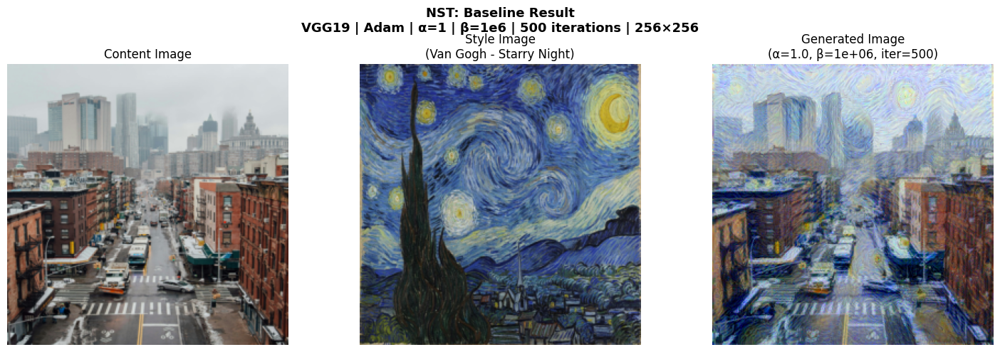

Comparison figure saved to: /content/NST_Project/outputs/result_comparison.png


In [ ]:
# Load the final generated image from the optimisation loop.
# Use the saved checkpoint file rather than the in-memory tensor to confirm the file saving pipeline worked
final_path = os.path.join(OUTPUT_DIR, f'generated_iter{NUM_ITERATIONS:04d}.png')
final_image = plt.imread(final_path)

# Three image comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Content image
axes[0].imshow(tensor_to_image(content_tensor))
axes[0].set_title('Content Image', fontsize=12)
axes[0].axis('off')

# Style image
axes[1].imshow(tensor_to_image(style_tensor))
axes[1].set_title('Style Image\n(Van Gogh - Starry Night)', fontsize=12)
axes[1].axis('off')

# Generated image
axes[2].imshow(final_image)
axes[2].set_title(f'Generated Image\n(α={ALPHA}, β={BETA:.0e}, iter={NUM_ITERATIONS})',
                  fontsize=12)
axes[2].axis('off')

plt.suptitle(
    'NST: Baseline Result\n'
    'VGG19 | Adam | α=1 | β=1e6 | 500 iterations | 256×256',
    fontsize=13,
    fontweight='bold'
)
plt.tight_layout()

# Save the comparison figure
comparison_path = os.path.join(OUTPUT_DIR, 'result_comparison.png')
plt.savefig(comparison_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Comparison figure saved to: {comparison_path}")

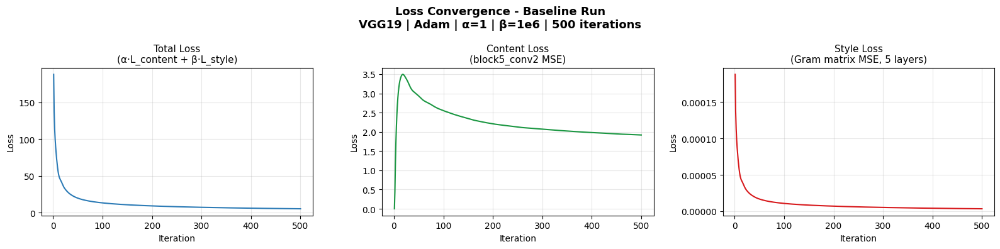

Loss curve saved to: /content/NST_Project/outputs/loss_curves.png


In [ ]:
# Loss curves
# Plotting three curves: total loss, content loss, and style loss over all 500 iterations.
iterations = list(range(1, NUM_ITERATIONS + 1))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Total loss
axes[0].plot(iterations, history['total'], color='#2c7bb6', linewidth=1.5)
axes[0].set_title('Total Loss\n(α·L_content + β·L_style)', fontsize=11)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

# Content loss
axes[1].plot(iterations, history['content'], color='#1a9641', linewidth=1.5)
axes[1].set_title('Content Loss\n(block5_conv2 MSE)', fontsize=11)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Loss')
axes[1].grid(True, alpha=0.3)

# Style loss
axes[2].plot(iterations, history['style'], color='#d7191c', linewidth=1.5)
axes[2].set_title('Style Loss\n(Gram matrix MSE, 5 layers)', fontsize=11)
axes[2].set_xlabel('Iteration')
axes[2].set_ylabel('Loss')
axes[2].grid(True, alpha=0.3)

plt.suptitle(
    'Loss Convergence - Baseline Run\n'
    'VGG19 | Adam | α=1 | β=1e6 | 500 iterations',
    fontsize=13,
    fontweight='bold'
)
plt.tight_layout()

# Save the loss curve figure
loss_curve_path = os.path.join(OUTPUT_DIR, 'loss_curves.png')
plt.savefig(loss_curve_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Loss curve saved to: {loss_curve_path}")

In [ ]:
# Numerical summary
# Print key metrics for this baseline run.
print("  Baseline Run: Quantitative summary")
print(f"  Architecture        : VGG19 (pretrained, frozen)")
print(f"  Optimiser           : Adam")
print(f"  Learning rate       : {LEARNING_RATE}")
print(f"  Iterations          : {NUM_ITERATIONS}")
print(f"  α(content weight)  : {ALPHA}")
print(f"  β(style weight)    : {BETA:.0e}")
print(f"  α/β ratio           : {ALPHA/BETA:.0e}")
print(f"  Image resolution    : {IMG_SIZE}×{IMG_SIZE}")
print(f"  Initial total loss  : {history['total'][0]:.4f}")
print(f"  Final total loss    : {history['total'][-1]:.4f}")
print(f"  Loss reduction      : {((history['total'][0] - history['total'][-1]) / history['total'][0] * 100):.1f}%")
print(f"  Initial content loss: {history['content'][0]:.4f}")
print(f"  Final content loss  : {history['content'][-1]:.4f}")
print(f"  Initial style loss  : {history['style'][0]:.6f}")
print(f"  Final style loss    : {history['style'][-1]:.6f}")
print(f"  Runtime             : {elapsed:.1f} seconds")


  Baseline Run: Quantitative summary
  Architecture        : VGG19 (pretrained, frozen)
  Optimiser           : Adam
  Learning rate       : 0.01
  Iterations          : 500
  α(content weight)  : 1.0
  β(style weight)    : 1e+06
  α/β ratio           : 1e-06
  Image resolution    : 256×256
  Initial total loss  : 188.0868
  Final total loss    : 5.3297
  Loss reduction      : 97.2%
  Initial content loss: 0.0000
  Final content loss  : 1.9191
  Initial style loss  : 0.000188
  Final style loss    : 0.000003
  Runtime             : 11.7 seconds


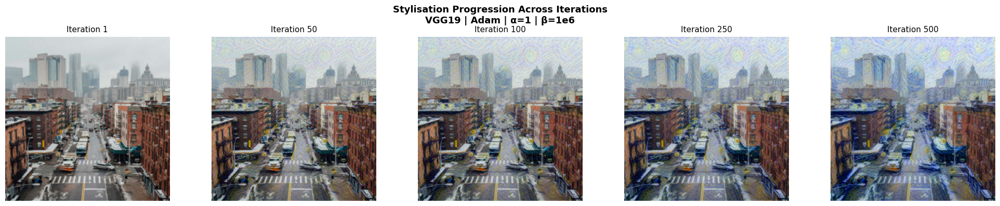

Checkpoint progression saved to: /content/NST_Project/outputs/checkpoint_progression.png


In [ ]:
# Load and display saved checkpoint images at key iterations to show how stylisation developed over the course of optimisation.
checkpoints = [1, 50, 100, 250, 500]
checkpoint_images = []

for it in checkpoints:
    path = os.path.join(OUTPUT_DIR, f'generated_iter{it:04d}.png')
    if os.path.exists(path):
        checkpoint_images.append((it, plt.imread(path)))
    else:
        print(f"Warning: checkpoint at iteration {it} not found, therefore skipping.")

fig, axes = plt.subplots(1, len(checkpoint_images), figsize=(4 * len(checkpoint_images), 4))

for ax, (it, img) in zip(axes, checkpoint_images):
    ax.imshow(img)
    ax.set_title(f'Iteration {it}', fontsize=11)
    ax.axis('off')

plt.suptitle(
    'Stylisation Progression Across Iterations\n'
    'VGG19 | Adam | α=1 | β=1e6',
    fontsize=13,
    fontweight='bold'
)
plt.tight_layout()

progression_path = os.path.join(OUTPUT_DIR, 'checkpoint_progression.png')
plt.savefig(progression_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Checkpoint progression saved to: {progression_path}")

## Section 7: Hyperparameter Sensitivity (α/β Ratio Variation)




In [ ]:
# Three controlled runs varying only the style weight β.
# All other settings are identical to the baseline run in Section 5.
# This directly investigates the primary hyperparameter governing the content-style balance in Gatys-style NST.

runs = [
    {
        'label'     : 'Run_B_low_style',
        'alpha'     : 1.0,
        'beta'      : 1e5,
        'description': 'Lowest style weight tested: more style dominant',
    },
    {
        'label'     : 'Run_baseline',
        'alpha'     : 1.0,
        'beta'      : 1e6,
        'description': 'Baseline: style dominant',
    },
    {
        'label'     : 'Run_A_high_style',
        'alpha'     : 1.0,
        'beta'      : 1e7,
        'description': 'Highest style weight tested: strongly style dominatant',
    },
]

# Fixed settings shared across all three runs
FIXED_LR         = 0.01
FIXED_ITERATIONS = 500
FIXED_LOG_EVERY  = 100

print("Experiment configuration:")
print(f"  Fixed: Adam | lr={FIXED_LR} | {FIXED_ITERATIONS} iterations | VGG19 | 256×256")
print(f"\n  Three runs:")
for r in runs:
    print(f"    α={r['alpha']} | β={r['beta']:.0e} | {r['description']}")

Experiment configuration:
  Fixed: Adam | lr=0.01 | 500 iterations | VGG19 | 256×256

  Three runs:
    α=1.0 | β=1e+05 | Lowest style weight tested: more style dominant
    α=1.0 | β=1e+06 | Baseline: style dominant
    α=1.0 | β=1e+07 | Highest style weight tested: strongly style dominatant


In [ ]:
def run_nst(alpha, beta, label, content_tensor, style_tensor,
            vgg, content_target, style_grams,
            content_idx, style_idx, all_idx,
            lr=0.01, num_iterations=500, log_every=100,
            output_dir=OUTPUT_DIR, seed=SEED):
    """
    Execute one complete NST optimisation run with the given hyperparameters.

    All settings other than alpha and beta are fixed, making this function
    suitable for controlled hyperparameter comparison experiments.

    """
    torch.manual_seed(seed)

    # Initialise generated image as a copy of content image
    generated = content_tensor.clone().requires_grad_(True)
    optimizer = optim.Adam([generated], lr=lr)

    history = {'total': [], 'content': [], 'style': []}
    content_layer_index = content_idx[0]

    print(f"\n RUN: {label}")
    print(f"   α={alpha} | β={beta:.0e} | lr={lr} | {num_iterations} iters")

    start = time.time()

    for iteration in range(1, num_iterations + 1):
        optimizer.zero_grad()

        gen_features = get_features(generated, vgg, all_idx)

        c_loss = content_loss(
            gen_features[content_layer_index], content_target
        )
        s_loss = style_loss(gen_features, style_grams, style_idx)

        total = alpha * c_loss + beta * s_loss
        total.backward()
        optimizer.step()

        history['content'].append(c_loss.item())
        history['style'].append(s_loss.item())
        history['total'].append(total.item())

        if iteration % log_every == 0 or iteration == 1:
            print(f"   iter {iteration:>4} | "
                  f"content: {c_loss.item():.4f} | "
                  f"style: {s_loss.item():.6f} | "
                  f"total: {total.item():.4f}")

    runtime = time.time() - start

    # Save the final generated image
    output_path = os.path.join(output_dir, f'{label}_iter{num_iterations:04d}.png')
    plt.imsave(output_path, tensor_to_image(generated))

    print(f"   Completed in {runtime:.1f}s | saved to {output_path}")

    return {
        'label'    : label,
        'alpha'    : alpha,
        'beta'     : beta,
        'generated': generated,
        'history'  : history,
        'runtime'  : runtime,
    }

In [ ]:
# Execute all three runs sequentially
results = []

for run_config in runs:
    result = run_nst(
        alpha          = run_config['alpha'],
        beta           = run_config['beta'],
        label          = run_config['label'],
        content_tensor = content_tensor,
        style_tensor   = style_tensor,
        vgg            = vgg,
        content_target = content_target,
        style_grams    = style_grams,
        content_idx    = content_idx,
        style_idx      = style_idx,
        all_idx        = all_idx,
        lr             = FIXED_LR,
        num_iterations = FIXED_ITERATIONS,
        log_every      = FIXED_LOG_EVERY,
    )
    results.append(result)



 RUN: Run_B_low_style
   α=1.0 | β=1e+05 | lr=0.01 | 500 iters
   iter    1 | content: 0.0000 | style: 0.000188 | total: 18.8087
   iter  100 | content: 0.5031 | style: 0.000016 | total: 2.1059
   iter  200 | content: 0.4306 | style: 0.000012 | total: 1.6055
   iter  300 | content: 0.3964 | style: 0.000010 | total: 1.3705
   iter  400 | content: 0.3748 | style: 0.000008 | total: 1.2216
   iter  500 | content: 0.3610 | style: 0.000008 | total: 1.1206
   Completed in 11.5s | saved to /content/NST_Project/outputs/Run_B_low_style_iter0500.png

 RUN: Run_baseline
   α=1.0 | β=1e+06 | lr=0.01 | 500 iters
   iter    1 | content: 0.0000 | style: 0.000188 | total: 188.0868
   iter  100 | content: 2.5454 | style: 0.000011 | total: 13.3197
   iter  200 | content: 2.2075 | style: 0.000007 | total: 9.2182
   iter  300 | content: 2.0633 | style: 0.000005 | total: 7.3183
   iter  400 | content: 1.9765 | style: 0.000004 | total: 6.1271
   iter  500 | content: 1.9144 | style: 0.000003 | total: 5.3270


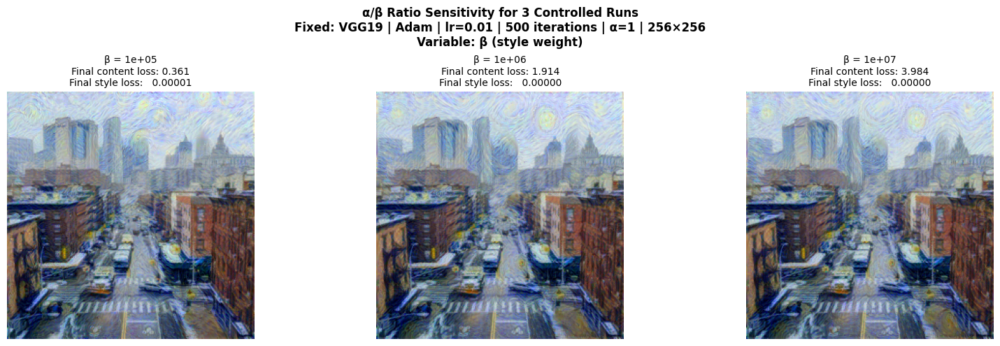

Comparison saved to: /content/NST_Project/outputs/hyperparameter_comparison.png


In [ ]:
# Three output comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, result in zip(axes, results):
    img_path = os.path.join(
        OUTPUT_DIR,
        f"{result['label']}_iter{FIXED_ITERATIONS:04d}.png"
    )
    ax.imshow(plt.imread(img_path))
    ax.set_title(
        f"β = {result['beta']:.0e}\n"
        f"Final content loss: {result['history']['content'][-1]:.3f}\n"
        f"Final style loss:   {result['history']['style'][-1]:.5f}",
        fontsize=10
    )
    ax.axis('off')

plt.suptitle(
    'α/β Ratio Sensitivity for 3 Controlled Runs\n'
    'Fixed: VGG19 | Adam | lr=0.01 | 500 iterations | α=1 | 256×256\n'
    'Variable: β (style weight)',
    fontsize=12,
    fontweight='bold'
)
plt.tight_layout()

comparison_path = os.path.join(OUTPUT_DIR, 'hyperparameter_comparison.png')
plt.savefig(comparison_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Comparison saved to: {comparison_path}")

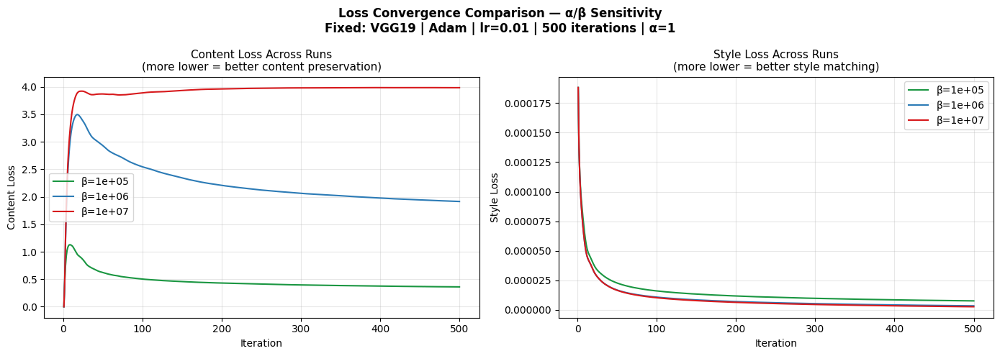

Loss curves saved to: /content/NST_Project/outputs/hyperparameter_loss_curves.png


In [ ]:
# Overlaid loss curves
# Plotting content loss and style loss for all three runs on the same axes displays the difference in convergence behaviour
iterations = list(range(1, FIXED_ITERATIONS + 1))

colours = {
    'Run_B_low_style'  : '#1a9641',
    'Run_baseline'     : '#2c7bb6',
    'Run_A_high_style' : '#d7191c',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for result in results:
    colour = colours[result['label']]
    label  = f"β={result['beta']:.0e}"

    # Content loss
    axes[0].plot(
        iterations,
        result['history']['content'],
        color=colour,
        linewidth=1.5,
        label=label
    )

    # Style loss
    axes[1].plot(
        iterations,
        result['history']['style'],
        color=colour,
        linewidth=1.5,
        label=label
    )

axes[0].set_title('Content Loss Across Runs\n(more lower = better content preservation)',
                   fontsize=11)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Content Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Style Loss Across Runs\n(more lower = better style matching)',
                   fontsize=11)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Style Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(
    'Loss Convergence Comparison — α/β Sensitivity\n'
    'Fixed: VGG19 | Adam | lr=0.01 | 500 iterations | α=1',
    fontsize=12,
    fontweight='bold'
)
plt.tight_layout()

curves_path = os.path.join(OUTPUT_DIR, 'hyperparameter_loss_curves.png')
plt.savefig(curves_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Loss curves saved to: {curves_path}")

In [ ]:
# Quantitative summary table
print("  α/β SENSITIVITY: Quantitative Comparison Table")
print(f"  {'Run':<22} {'β':>6} {'Init C':>8} {'Final C':>8} "
      f"{'Init S':>10} {'Final S':>10} {'Time':>7}")

for result in results:
    h = result['history']
    print(f"  {result['label']:<22} "
          f"{result['beta']:>6.0e} "
          f"{h['content'][0]:>8.3f} "
          f"{h['content'][-1]:>8.3f} "
          f"{h['style'][0]:>10.6f} "
          f"{h['style'][-1]:>10.6f} "
          f"{result['runtime']:>6.1f}s")

  α/β SENSITIVITY: Quantitative Comparison Table
  Run                         β   Init C  Final C     Init S    Final S    Time
  Run_B_low_style         1e+05    0.000    0.361   0.000188   0.000008   11.5s
  Run_baseline            1e+06    0.000    1.914   0.000188   0.000003   11.5s
  Run_A_high_style        1e+07    0.000    3.984   0.000188   0.000003   11.7s


In [ ]:
# Iteration-budget variation
# here we vary the number of optimisation steps, holding α/β at the baseline.
# The geometric progression (500 to 1000 to 2000) probes diminishing returns: if the loss has genuinely plateaued by 500, doubling and quadrupling the budget should give only marginal further
# reduction.
# This is a direct empirical check on the convergence-rate metric in Section 13.
# Everything except the iteration count is fixed at the baseline (VGG19,α=1, β=1e6, Adam lr=0.01, seed=42) on the baseline content/style pair.

ITER_BUDGETS = [500, 1000, 2000]

iter_results = []
for n_iters in ITER_BUDGETS:
    r = run_nst(
        alpha=ALPHA, beta=BETA, label=f'Iter_{n_iters:04d}',
        content_tensor=content_tensor, style_tensor=style_tensor, vgg=vgg,
        content_target=content_target, style_grams=style_grams,
        content_idx=content_idx, style_idx=style_idx, all_idx=all_idx,
        lr=LEARNING_RATE, num_iterations=n_iters, log_every=max(n_iters // 5, 1),
    )
    r['num_iterations'] = n_iters
    iter_results.append(r)

print(f"\nIteration-budget variation complete: {len(iter_results)} runs.")


 RUN: Iter_0500
   α=1.0 | β=1e+06 | lr=0.01 | 500 iters
   iter    1 | content: 0.0000 | style: 0.000188 | total: 188.0868
   iter  100 | content: 2.5501 | style: 0.000011 | total: 13.3192
   iter  200 | content: 2.2111 | style: 0.000007 | total: 9.2220
   iter  300 | content: 2.0704 | style: 0.000005 | total: 7.3205
   iter  400 | content: 1.9856 | style: 0.000004 | total: 6.1300
   iter  500 | content: 1.9226 | style: 0.000003 | total: 5.3298
   Completed in 11.8s | saved to /content/NST_Project/outputs/Iter_0500_iter0500.png

 RUN: Iter_1000
   α=1.0 | β=1e+06 | lr=0.01 | 1000 iters
   iter    1 | content: 0.0000 | style: 0.000188 | total: 188.0868
   iter  200 | content: 2.2127 | style: 0.000007 | total: 9.2209
   iter  400 | content: 1.9835 | style: 0.000004 | total: 6.1318
   iter  600 | content: 1.8698 | style: 0.000003 | total: 4.8049
   iter  800 | content: 1.7921 | style: 0.000002 | total: 4.2381
   iter 1000 | content: 1.7409 | style: 0.000002 | total: 3.9553
   Completed 

In [ ]:
print("  Iteration Budget Variation (VGG19, baseline α/β, cityscape x Starry Night)")
print("-" * 74)
print(f"  {'Iterations':>10} {'Final total':>14} {'Final content':>15} "
      f"{'Final style':>13} {'Runtime':>9}")
print("-" * 74)
for r in iter_results:
    h = r['history']
    print(f"  {r['num_iterations']:>10} {h['total'][-1]:>14.4f} "
          f"{h['content'][-1]:>15.4f} {h['style'][-1]:>13.6f} {r['runtime']:>8.1f}s")
print("-" * 74)

base = iter_results[0]['history']['total'][-1]
for r in iter_results[1:]:
    ft = r['history']['total'][-1]
    print(f"  {r['num_iterations']} iters vs 500 iters: "
          f"final total loss {(ft - base) / base * 100:+.2f}%")

  Iteration Budget Variation (VGG19, baseline α/β, cityscape x Starry Night)
--------------------------------------------------------------------------
  Iterations    Final total   Final content   Final style   Runtime
--------------------------------------------------------------------------
         500         5.3298          1.9226      0.000003     11.8s
        1000         3.9553          1.7409      0.000002     23.8s
        2000         3.3739          1.6066      0.000002     48.6s
--------------------------------------------------------------------------
  1000 iters vs 500 iters: final total loss -25.79%
  2000 iters vs 500 iters: final total loss -36.70%


## Section 8: Structural Similarity Index (SSIM) Evaluation

SSIM (Wang et al., 2004) provides a perceptually-grounded measure of how much content structure is retained after stylisation. Unlike content loss, which measures distance in VGG feature space, SSIM compares luminance, contrast, and structure directly at the image level.

SSIM is used here as a relative measure across experimental conditions applied to the same content image, not as an absolute quality score. Heavy stylisation is intended to alter texture, so a lower SSIM reflects stronger stylisation rather than system failure.

In [ ]:
from skimage.metrics import structural_similarity as ssim
import numpy as np


def compute_ssim(reference_tensor, generated_tensor):
    """
    Compute the Structural Similarity Index between a reference image and a
    generated image.
    """
    # Denormalise both tensors to [0,1] RGB numpy arrays of shape [H, W, 3].
    # tensor_to_image() also detaches from the autograd graph, which is required because the generated tensor has requires_grad=True.
    reference_np = tensor_to_image(reference_tensor)
    generated_np = tensor_to_image(generated_tensor)

    score = ssim(
        reference_np,
        generated_np,
        channel_axis=2,   # RGB channels are the last axis after permute
        data_range=1.0    # pixel values lie in [0,1], not [0,255]
    )

    return float(score)


# Sanity check as an image compared against itself should score exactly 1.0.
# This is a unit test of the metric implementation
# if it does not return 1.0, the denormalisation or channel ordering is wrong.
self_check = compute_ssim(content_tensor, content_tensor)
print(f"Sanity check (content vs itself): SSIM = {self_check:.4f}")

Sanity check (content vs itself): SSIM = 1.0000


In [ ]:
# Compute SSIM across the three α/β sensitivity runs
# All three runs share the same content image, architecture, optimiser, and iteration count. Only β differs. SSIM differences are therefore attributable to the style weight alone.
ssim_scores = {}

for result in results:
    score = compute_ssim(content_tensor, result['generated'])
    ssim_scores[result['label']] = score
    result['ssim'] = score

print("  SSIM Results: α/β Sensitivity runs")
print("-" * 72)
print(f"  {'Run':<22} {'β':>8} {'SSIM':>8} {'Final C-loss':>14} {'Final S-loss':>14}")
print("-" * 72)

for result in results:
    h = result['history']
    print(f"  {result['label']:<22} "
          f"{result['beta']:>8.0e} "
          f"{result['ssim']:>8.4f} "
          f"{h['content'][-1]:>14.3f} "
          f"{h['style'][-1]:>14.6f}")

print("-" * 72)

  SSIM Results: α/β Sensitivity runs
------------------------------------------------------------------------
  Run                           β     SSIM   Final C-loss   Final S-loss
------------------------------------------------------------------------
  Run_B_low_style           1e+05   0.7105          0.361       0.000008
  Run_baseline              1e+06   0.7085          1.914       0.000003
  Run_A_high_style          1e+07   0.7126          3.984       0.000003
------------------------------------------------------------------------


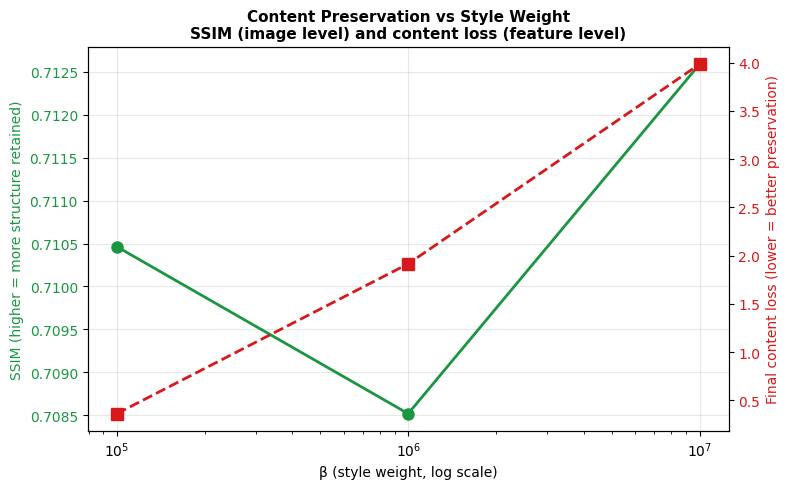

Saved to: /content/NST_Project/outputs/ssim_vs_content_loss.png


In [ ]:
# SSIM vs content loss across β values
# Plotting both metrics on the same axis shows whether they agree. If SSIM falls as content loss rises, the two independent measures corroborate each other

betas        = [r['beta'] for r in results]
ssim_values  = [r['ssim'] for r in results]
content_vals = [r['history'][-1] if False else r['history']['content'][-1]
                for r in results]

fig, ax1 = plt.subplots(figsize=(8, 5))

# SSIM on the left axis
colour_ssim = '#1a9641'
ax1.plot(betas, ssim_values, 'o-', color=colour_ssim,
         linewidth=2, markersize=8, label='SSIM')
ax1.set_xscale('log')
ax1.set_xlabel('β (style weight, log scale)')
ax1.set_ylabel('SSIM (higher = more structure retained)', color=colour_ssim)
ax1.tick_params(axis='y', labelcolor=colour_ssim)
ax1.grid(True, alpha=0.3)

# Content loss on the right axis
ax2 = ax1.twinx()
colour_closs = '#d7191c'
ax2.plot(betas, content_vals, 's--', color=colour_closs,
         linewidth=2, markersize=8, label='Final content loss')
ax2.set_ylabel('Final content loss (lower = better preservation)',
               color=colour_closs)
ax2.tick_params(axis='y', labelcolor=colour_closs)

plt.title('Content Preservation vs Style Weight\n'
          'SSIM (image level) and content loss (feature level)',
          fontsize=11, fontweight='bold')

fig.tight_layout()
ssim_plot_path = os.path.join(OUTPUT_DIR, 'ssim_vs_content_loss.png')
plt.savefig(ssim_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to: {ssim_plot_path}")

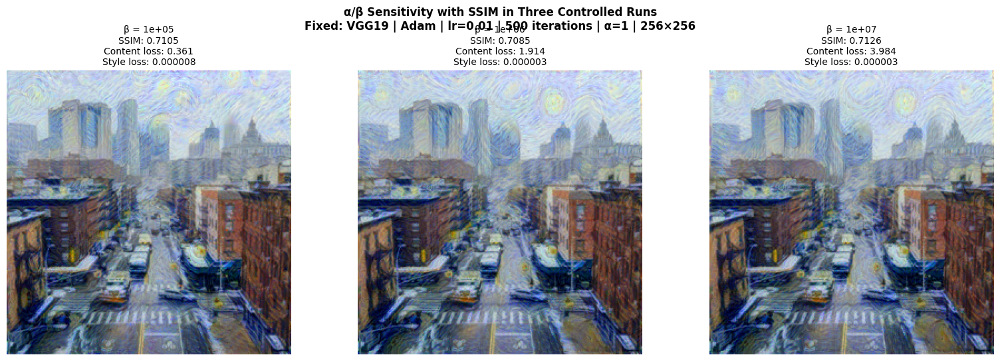

Saved to: /content/NST_Project/outputs/ssim_annotated_comparison.png


In [ ]:
# Three outputs annotated with SSIM
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))

for ax, result in zip(axes, results):
    img_path = os.path.join(
        OUTPUT_DIR,
        f"{result['label']}_iter{FIXED_ITERATIONS:04d}.png"
    )
    ax.imshow(plt.imread(img_path))
    ax.set_title(
        f"β = {result['beta']:.0e}\n"
        f"SSIM: {result['ssim']:.4f}\n"
        f"Content loss: {result['history']['content'][-1]:.3f}\n"
        f"Style loss: {result['history']['style'][-1]:.6f}",
        fontsize=10
    )
    ax.axis('off')

plt.suptitle(
    'α/β Sensitivity with SSIM in Three Controlled Runs\n'
    'Fixed: VGG19 | Adam | lr=0.01 | 500 iterations | α=1 | 256×256',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()

annotated_path = os.path.join(OUTPUT_DIR, 'ssim_annotated_comparison.png')
plt.savefig(annotated_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to: {annotated_path}")

## Section 9: Architecture Comparison (VGG16 vs VGG19)

Controlled comparison isolating the effect of feature extractor depth on content preservation, style representation, and convergence behaviour.

Fixed across both runs: content image, style image, α=1, β=1e6, Adam, lr=0.01, 500 iterations, 256×256 resolution, random seed 42.

Variable: the pretrained CNN used for feature extraction (VGG16 vs VGG19).

Gatys et al. (2016) fix VGG19 as the loss network without testing whether a
shallower feature extractor changes the result. This experiment addresses
RQ2 directly.

In [ ]:
# VGG16 Model Loading
from torchvision.models import vgg16, VGG16_Weights

def load_vgg16(device):
    """
    Load a pretrained VGG16 network for use as a fixed feature extractor.

    ImageNet-pretrained weights, all parameters frozen, classifier head discarded, eval mode. Keeping the
    loading procedure identical is what makes the architecture comparison a controlled experiment

    VGG16 has 13 convolutional layers against VGG19's 16, giving a shallower feature hierarchy while retaining the same architectural family
    """
    weights = VGG16_Weights.DEFAULT
    model = vgg16(weights=weights).features

    for param in model.parameters():
        param.requires_grad = False

    return model.to(device).eval()


vgg16_model = load_vgg16(device)
print(f"Layers in vgg16.features: {len(vgg16_model)}  (VGG19 has {len(vgg)})")

Layers in vgg16.features: 31  (VGG19 has 37)


In [ ]:
# VGG16 is shorter than VGG19, so the same named layers sit at different numerical indices.
# Selecting the same named layers (block1_conv1 through
# block5_conv1 for style, block5_conv2 for content) keeps the comparison conceptually fair
CONTENT_LAYER_VGG16 = {'block5_conv2': 26}

STYLE_LAYERS_VGG16 = {
    'block1_conv1': 0,
    'block2_conv1': 5,
    'block3_conv1': 10,
    'block4_conv1': 17,
    'block5_conv1': 24,
}

# Verification: every selected index must be a Conv2d layer.
print("VGG16 content layer:")
for name, idx in CONTENT_LAYER_VGG16.items():
    print(f"  [{idx:>2}] {name:<14} -> {vgg16_model[idx]}")

print("\nVGG16 style layers:")
for name, idx in STYLE_LAYERS_VGG16.items():
    print(f"  [{idx:>2}] {name:<14} -> {vgg16_model[idx]}")

VGG16 content layer:
  [26] block5_conv2   -> Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))

VGG16 style layers:
  [ 0] block1_conv1   -> Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  [ 5] block2_conv1   -> Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  [10] block3_conv1   -> Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  [17] block4_conv1   -> Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  [24] block5_conv1   -> Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))


In [ ]:
# Precompute fixed targets using VGG16
content_idx_16 = list(CONTENT_LAYER_VGG16.values())
style_idx_16   = list(STYLE_LAYERS_VGG16.values())
all_idx_16     = content_idx_16 + style_idx_16

# Content target from VGG16's block5_conv2
content_targets_16 = get_features(content_tensor, vgg16_model, content_idx_16)
content_target_16  = content_targets_16[content_idx_16[0]]

# Style targets: Gram matrices at VGG16's five style layers
style_features_16 = get_features(style_tensor, vgg16_model, style_idx_16)
style_grams_16 = {idx: gram_matrix(style_features_16[idx]) for idx in style_idx_16}

print(f"Content target shape (block5_conv2): {content_target_16.shape}")
print("\n VGG16 Gram matrix shapes:")
for name, idx in STYLE_LAYERS_VGG16.items():
    print(f"  {name:<14} (idx {idx:>2}): {style_grams_16[idx].shape}")

Content target shape (block5_conv2): torch.Size([1, 512, 16, 16])

 VGG16 Gram matrix shapes:
  block1_conv1   (idx  0): torch.Size([64, 64])
  block2_conv1   (idx  5): torch.Size([128, 128])
  block3_conv1   (idx 10): torch.Size([256, 256])
  block4_conv1   (idx 17): torch.Size([512, 512])
  block5_conv1   (idx 24): torch.Size([512, 512])


In [ ]:
# Controlled architecture comparison
ARCH_ALPHA      = 1.0
ARCH_BETA       = 1e6
ARCH_LR         = 0.01
ARCH_ITERATIONS = 500
ARCH_LOG_EVERY  = 100

print("Architecture comparison with fixed configuration:")
print(f"  α={ARCH_ALPHA} | β={ARCH_BETA:.0e} | lr={ARCH_LR} | "
      f"{ARCH_ITERATIONS} iterations | seed={SEED}")

arch_results = []

# Run 1: VGG19
result_vgg19 = run_nst(
    alpha          = ARCH_ALPHA,
    beta           = ARCH_BETA,
    label          = 'Arch_VGG19',
    content_tensor = content_tensor,
    style_tensor   = style_tensor,
    vgg            = vgg,
    content_target = content_target,
    style_grams    = style_grams,
    content_idx    = content_idx,
    style_idx      = style_idx,
    all_idx        = all_idx,
    lr             = ARCH_LR,
    num_iterations = ARCH_ITERATIONS,
    log_every      = ARCH_LOG_EVERY,
)
result_vgg19['architecture'] = 'VGG19'
result_vgg19['depth'] = 16      # convolutional layers
arch_results.append(result_vgg19)

# Run 2: VGG16
result_vgg16 = run_nst(
    alpha          = ARCH_ALPHA,
    beta           = ARCH_BETA,
    label          = 'Arch_VGG16',
    content_tensor = content_tensor,
    style_tensor   = style_tensor,
    vgg            = vgg16_model,
    content_target = content_target_16,
    style_grams    = style_grams_16,
    content_idx    = content_idx_16,
    style_idx      = style_idx_16,
    all_idx        = all_idx_16,
    lr             = ARCH_LR,
    num_iterations = ARCH_ITERATIONS,
    log_every      = ARCH_LOG_EVERY,
)
result_vgg16['architecture'] = 'VGG16'
result_vgg16['depth'] = 13
arch_results.append(result_vgg16)

Architecture comparison with fixed configuration:
  α=1.0 | β=1e+06 | lr=0.01 | 500 iterations | seed=42

 RUN: Arch_VGG19
   α=1.0 | β=1e+06 | lr=0.01 | 500 iters
   iter    1 | content: 0.0000 | style: 0.000188 | total: 188.0868
   iter  100 | content: 2.5461 | style: 0.000011 | total: 13.3216
   iter  200 | content: 2.2071 | style: 0.000007 | total: 9.2238
   iter  300 | content: 2.0691 | style: 0.000005 | total: 7.3200
   iter  400 | content: 1.9814 | style: 0.000004 | total: 6.1296
   iter  500 | content: 1.9232 | style: 0.000003 | total: 5.3342
   Completed in 12.3s | saved to /content/NST_Project/outputs/Arch_VGG19_iter0500.png

 RUN: Arch_VGG16
   α=1.0 | β=1e+06 | lr=0.01 | 500 iters
   iter    1 | content: 0.0000 | style: 0.000168 | total: 167.8656
   iter  100 | content: 2.4182 | style: 0.000010 | total: 12.6661
   iter  200 | content: 2.1009 | style: 0.000007 | total: 8.7332
   iter  300 | content: 1.9168 | style: 0.000005 | total: 6.7906
   iter  400 | content: 1.8168 | st

In [ ]:
# Compute SSIM and assemble comparison table
for r in arch_results:
    r['ssim'] = compute_ssim(content_tensor, r['generated'])

print("  Architecture Comparison of VGG16 vs VGG19")
print("  Fixed: α=1 | β=1e6 | Adam lr=0.01 | 500 iters | 256×256 | seed=42")
print("-" * 88)
print(f"  {'Architecture':<14} {'Conv layers':>12} {'Final C-loss':>14} "
      f"{'Final S-loss':>14} {'SSIM':>8} {'Runtime':>10}")
print("-" * 88)

for r in arch_results:
    h = r['history']
    print(f"  {r['architecture']:<14} "
          f"{r['depth']:>12} "
          f"{h['content'][-1]:>14.4f} "
          f"{h['style'][-1]:>14.6f} "
          f"{r['ssim']:>8.4f} "
          f"{r['runtime']:>9.1f}s")

# Relative differences, computed with VGG19 as the reference baseline
v19, v16 = arch_results[0], arch_results[1]
c_diff = ((v16['history']['content'][-1] - v19['history']['content'][-1])
          / v19['history']['content'][-1] * 100)
s_diff = ((v16['history']['style'][-1] - v19['history']['style'][-1])
          / v19['history']['style'][-1] * 100)
ssim_diff = v16['ssim'] - v19['ssim']
time_diff = ((v16['runtime'] - v19['runtime']) / v19['runtime'] * 100)

print("  VGG16 relative to VGG19 baseline:")
print(f"    Content loss : {c_diff:+.1f}%")
print(f"    Style loss   : {s_diff:+.1f}%")
print(f"    SSIM         : {ssim_diff:+.4f}")
print(f"    Runtime      : {time_diff:+.1f}%")

  Architecture Comparison of VGG16 vs VGG19
  Fixed: α=1 | β=1e6 | Adam lr=0.01 | 500 iters | 256×256 | seed=42
----------------------------------------------------------------------------------------
  Architecture    Conv layers   Final C-loss   Final S-loss     SSIM    Runtime
----------------------------------------------------------------------------------------
  VGG19                    16         1.9232       0.000003   0.7087      12.3s
  VGG16                    13         1.7550       0.000003   0.6927      10.3s
  VGG16 relative to VGG19 baseline:
    Content loss : -8.7%
    Style loss   : -8.3%
    SSIM         : -0.0159
    Runtime      : -16.1%


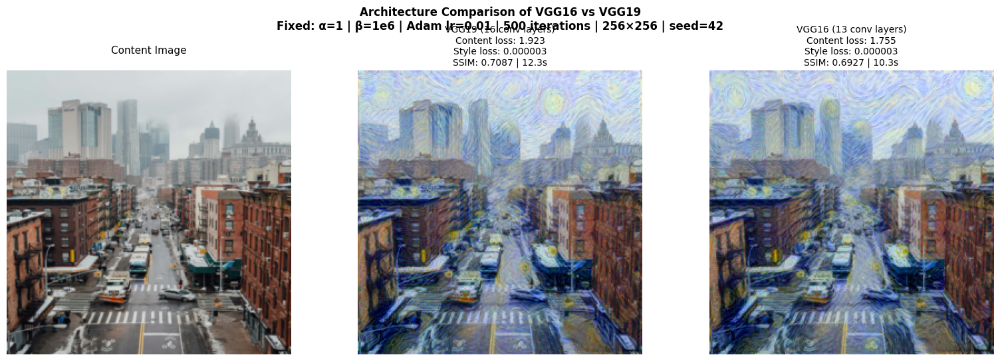

Saved to: /content/NST_Project/outputs/architecture_comparison.png


In [ ]:
# Visual comparison of content, VGG19 output, VGG16 output
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))

axes[0].imshow(tensor_to_image(content_tensor))
axes[0].set_title('Content Image\n', fontsize=11)
axes[0].axis('off')

for ax, r in zip(axes[1:], arch_results):
    img_path = os.path.join(
        OUTPUT_DIR, f"{r['label']}_iter{ARCH_ITERATIONS:04d}.png"
    )
    ax.imshow(plt.imread(img_path))
    ax.set_title(
        f"{r['architecture']} ({r['depth']} conv layers)\n"
        f"Content loss: {r['history']['content'][-1]:.3f}\n"
        f"Style loss: {r['history']['style'][-1]:.6f}\n"
        f"SSIM: {r['ssim']:.4f} | {r['runtime']:.1f}s",
        fontsize=10
    )
    ax.axis('off')

plt.suptitle(
    'Architecture Comparison of VGG16 vs VGG19\n'
    'Fixed: α=1 | β=1e6 | Adam lr=0.01 | 500 iterations | 256×256 | seed=42',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()

arch_img_path = os.path.join(OUTPUT_DIR, 'architecture_comparison.png')
plt.savefig(arch_img_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to: {arch_img_path}")

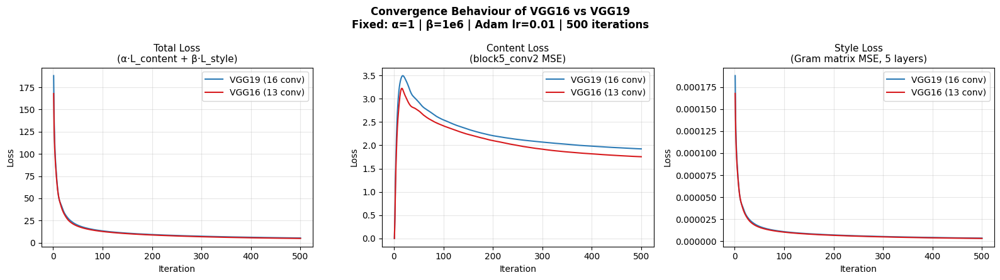

Saved to: /content/NST_Project/outputs/architecture_loss_curves.png


In [ ]:
# Convergence comparison
# Overlaying both runs shows whether feature extractor depth changes the shape of convergence, not just the final values. Different curve shapes would
# indicate the architectures reach their solutions by different routes.

iters = list(range(1, ARCH_ITERATIONS + 1))
arch_colours = {'VGG19': '#2c7bb6', 'VGG16': '#d7191c'}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for r in arch_results:
    c = arch_colours[r['architecture']]
    lbl = f"{r['architecture']} ({r['depth']} conv)"
    axes[0].plot(iters, r['history']['total'],   color=c, linewidth=1.5, label=lbl)
    axes[1].plot(iters, r['history']['content'], color=c, linewidth=1.5, label=lbl)
    axes[2].plot(iters, r['history']['style'],   color=c, linewidth=1.5, label=lbl)

titles = [
    'Total Loss\n(α·L_content + β·L_style)',
    'Content Loss\n(block5_conv2 MSE)',
    'Style Loss\n(Gram matrix MSE, 5 layers)',
]
for ax, t in zip(axes, titles):
    ax.set_title(t, fontsize=11)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle(
    'Convergence Behaviour of VGG16 vs VGG19\n'
    'Fixed: α=1 | β=1e6 | Adam lr=0.01 | 500 iterations',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()

arch_curves_path = os.path.join(OUTPUT_DIR, 'architecture_loss_curves.png')
plt.savefig(arch_curves_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to: {arch_curves_path}")

In [ ]:
# Multi-pair architecture comparison
# Earlier the comparison above uses a single pair (cityscape x Starry Night).
#One pair cannot separate a genuine VGG16/VGG19 architectural effect from an artefact of that specific image combination.
# Here we repeat the same controlled comparison across three further pairs spanning different content types and style domains.

# Pairs vary both axes (with the baseline pair above, this covers all three
# content images and all four style domains):
#   portrait  x chinese_ink
#   landscape x op_art
#   cityscape x pop_art

def build_targets(content_t, style_t, network, c_idx, s_idx):
    """
    Precompute content and style targets for one image pair on one network.
    """
    c_targets = get_features(content_t, network, c_idx)
    c_target  = c_targets[c_idx[0]]
    s_feats   = get_features(style_t, network, s_idx)
    s_grams   = {idx: gram_matrix(s_feats[idx]) for idx in s_idx}
    return c_target, s_grams


# Extra pairs referenced by nam from the central registry loaded in Section 2.
extra_pairs = [
    ('portrait',  'chinese_ink'),
    ('landscape', 'op_art'),
    ('cityscape', 'pop_art'),
]

multi_arch_results = []

for c_name, s_name in extra_pairs:
    c_tensor   = content_tensors[c_name]
    s_tensor   = style_tensors[s_name]
    pair_label = f"{c_name}__{s_name}"

    # VGG19 run same hyperparameters as the baseline architecture comparison
    t19_c, t19_g = build_targets(c_tensor, s_tensor, vgg, content_idx, style_idx)
    r19 = run_nst(
        alpha=ARCH_ALPHA, beta=ARCH_BETA, label=f'Arch_{pair_label}_VGG19',
        content_tensor=c_tensor, style_tensor=s_tensor, vgg=vgg,
        content_target=t19_c, style_grams=t19_g,
        content_idx=content_idx, style_idx=style_idx, all_idx=all_idx,
        lr=ARCH_LR, num_iterations=ARCH_ITERATIONS, log_every=ARCH_LOG_EVERY,
    )
    r19.update({'architecture': 'VGG19', 'depth': 16, 'pair': pair_label,
                'content_name': c_name, 'style_name': s_name})
    r19['ssim'] = compute_ssim(c_tensor, r19['generated'])

    # VGG16 run same pair, samee hyperparameters, VGG16 layer indices/targets
    t16_c, t16_g = build_targets(c_tensor, s_tensor, vgg16_model,
                                 content_idx_16, style_idx_16)
    r16 = run_nst(
        alpha=ARCH_ALPHA, beta=ARCH_BETA, label=f'Arch_{pair_label}_VGG16',
        content_tensor=c_tensor, style_tensor=s_tensor, vgg=vgg16_model,
        content_target=t16_c, style_grams=t16_g,
        content_idx=content_idx_16, style_idx=style_idx_16, all_idx=all_idx_16,
        lr=ARCH_LR, num_iterations=ARCH_ITERATIONS, log_every=ARCH_LOG_EVERY,
    )
    r16.update({'architecture': 'VGG16', 'depth': 13, 'pair': pair_label,
                'content_name': c_name, 'style_name': s_name})
    r16['ssim'] = compute_ssim(c_tensor, r16['generated'])

    multi_arch_results.extend([r19, r16])

print(f"\nMulti-pair architecture comparison complete: "
      f"{len(multi_arch_results)} runs across {len(extra_pairs)} pairs.")


 RUN: Arch_portrait__chinese_ink_VGG19
   α=1.0 | β=1e+06 | lr=0.01 | 500 iters
   iter    1 | content: 0.0000 | style: 0.000113 | total: 113.4166
   iter  100 | content: 1.5551 | style: 0.000005 | total: 6.3838
   iter  200 | content: 1.3823 | style: 0.000003 | total: 4.5532
   iter  300 | content: 1.2926 | style: 0.000002 | total: 3.7250
   iter  400 | content: 1.2276 | style: 0.000002 | total: 3.2399
   iter  500 | content: 1.1828 | style: 0.000002 | total: 2.9255
   Completed in 12.3s | saved to /content/NST_Project/outputs/Arch_portrait__chinese_ink_VGG19_iter0500.png

 RUN: Arch_portrait__chinese_ink_VGG16
   α=1.0 | β=1e+06 | lr=0.01 | 500 iters
   iter    1 | content: 0.0000 | style: 0.000135 | total: 135.4062
   iter  100 | content: 1.6790 | style: 0.000006 | total: 7.3577
   iter  200 | content: 1.4353 | style: 0.000004 | total: 5.0592
   iter  300 | content: 1.3251 | style: 0.000003 | total: 4.0542
   iter  400 | content: 1.2534 | style: 0.000002 | total: 3.4774
   iter  50

In [ ]:
# Combined per pair summary: does the VGG16 VGG19 gap hold across pairs?
for r in arch_results:
    r.setdefault('pair', 'cityscape__starry_night')

all_arch = arch_results + multi_arch_results

print("  Multi-pair Architecture Comparison (VGG16 vs VGG19)")
print("  Fixed: α=1 | β=1e6 | Adam lr=0.01 | 500 iters | 256×256 | seed=42")
print("-" * 92)
print(f"  {'Pair':<26} {'Arch':<7} {'Final C':>10} {'Final S':>12} "
      f"{'SSIM':>8} {'Runtime':>9}")
print("-" * 92)

pairs_seen = []
for r in all_arch:
    if r['pair'] not in pairs_seen:
        pairs_seen.append(r['pair'])

for p in pairs_seen:
    rows = [r for r in all_arch if r['pair'] == p]
    v19 = next(r for r in rows if r['architecture'] == 'VGG19')
    v16 = next(r for r in rows if r['architecture'] == 'VGG16')
    for r in (v19, v16):
        h = r['history']
        print(f"  {p:<26} {r['architecture']:<7} "
              f"{h['content'][-1]:>10.4f} {h['style'][-1]:>12.6f} "
              f"{r['ssim']:>8.4f} {r['runtime']:>8.1f}s")
    print(f"  {'  Change in SSIM (VGG16 − VGG19)':<34}{v16['ssim'] - v19['ssim']:>+8.4f}")
    print("-" * 92)

  Multi-pair Architecture Comparison (VGG16 vs VGG19)
  Fixed: α=1 | β=1e6 | Adam lr=0.01 | 500 iters | 256×256 | seed=42
--------------------------------------------------------------------------------------------
  Pair                       Arch       Final C      Final S     SSIM   Runtime
--------------------------------------------------------------------------------------------
  cityscape__starry_night    VGG19       1.9232     0.000003   0.7087     12.3s
  cityscape__starry_night    VGG16       1.7550     0.000003   0.6927     10.3s
    Change in SSIM (VGG16 − VGG19)   -0.0159
--------------------------------------------------------------------------------------------
  portrait__chinese_ink      VGG19       1.1828     0.000002   0.7066     12.3s
  portrait__chinese_ink      VGG16       1.1987     0.000002   0.7031     10.4s
    Change in SSIM (VGG16 − VGG19)   -0.0035
--------------------------------------------------------------------------------------------
  landscape__op_

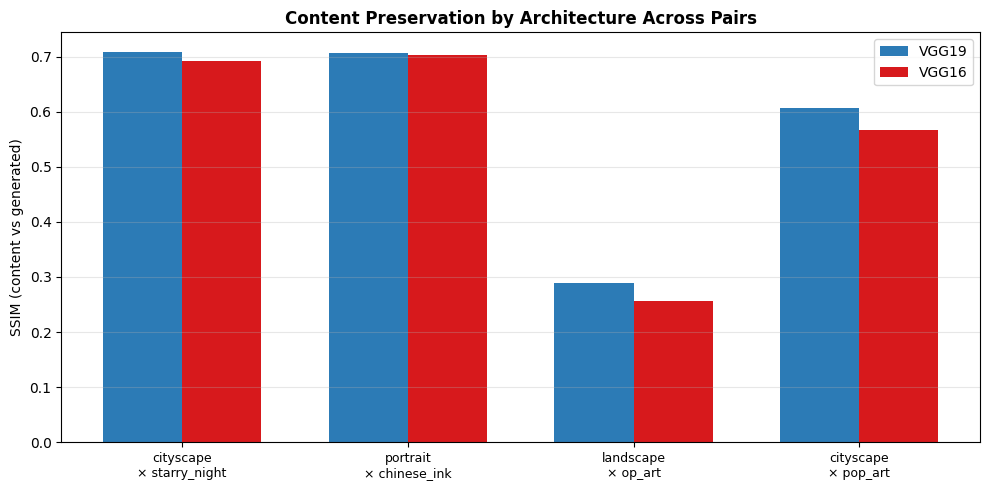

In [ ]:
import numpy as np

labels = [p.replace('__', '\n× ') for p in pairs_seen]
v19_ssim = [next(r for r in all_arch if r['pair']==p and r['architecture']=='VGG19')['ssim'] for p in pairs_seen]
v16_ssim = [next(r for r in all_arch if r['pair']==p and r['architecture']=='VGG16')['ssim'] for p in pairs_seen]

x = np.arange(len(pairs_seen))
w = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, v19_ssim, w, label='VGG19', color='#2c7bb6')
ax.bar(x + w/2, v16_ssim, w, label='VGG16', color='#d7191c')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('SSIM (content vs generated)')
ax.set_title('Content Preservation by Architecture Across Pairs', fontweight='bold')
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'architecture_multipair_ssim.png'), dpi=150, bbox_inches='tight')
plt.show()

## Section 10: Style Domain Comparison

Crosses multiple content images with multiple style domains to test whether the system's behaviour generalises beyond the single cityscape–Starry Night pairing

**Matrix:** 3 content images × 4 style domains = 12 combinations.
- Content: cityscape (building), portrait (person), landscape (nature)
- Style:   Starry Night (Impressionist brushstroke), Chinese ink (line/wash), Pop Art by Andy Warhol, Optical Art (geometric style)

**Fixed across all runs:** VGG19, α=1, β=1e6, Adam, lr=0.01, 500 iterations,
256×256, seed=42.

Style domains are used solely as sources of visually distinct texture, colour, and line characteristics. No claims are made about cultural, religious, or psychological meaning

In [ ]:
# This section reuses content_tensors / style_tensors directly.
print(f"Matrix inputs ready: {len(content_tensors)} content × "
      f"{len(style_tensors)} style = "
      f"{len(content_tensors) * len(style_tensors)} combinations")

Matrix inputs ready: 3 content × 4 style = 12 combinations


In [ ]:
# For each content, style pair, the style targets must be recomputed because the style image changes; the content target must be recomputed because the
# content image changes. Everything else (architecture, α, β, optimiser,iterations, seed) stays fixed, so any difference across cells of the matrix
# is attributable to the content/style inputs alone.

MATRIX_ALPHA      = 1.0
MATRIX_BETA       = 1e6
MATRIX_LR         = 0.01
MATRIX_ITERATIONS = 500
MATRIX_LOG_EVERY  = 250

matrix_results = []

for c_name, c_tensor in content_tensors.items():
    c_targets = get_features(c_tensor, vgg, content_idx)
    c_target  = c_targets[content_idx[0]]

    for s_name, s_tensor in style_tensors.items():
        # Precompute this style image's Gram matrices
        s_feats = get_features(s_tensor, vgg, style_idx)
        s_grams = {idx: gram_matrix(s_feats[idx]) for idx in style_idx}

        label = f"{c_name}__{s_name}"

        result = run_nst(
            alpha          = MATRIX_ALPHA,
            beta           = MATRIX_BETA,
            label          = label,
            content_tensor = c_tensor,
            style_tensor   = s_tensor,
            vgg            = vgg,
            content_target = c_target,
            style_grams    = s_grams,
            content_idx    = content_idx,
            style_idx      = style_idx,
            all_idx        = all_idx,
            lr             = MATRIX_LR,
            num_iterations = MATRIX_ITERATIONS,
            log_every      = MATRIX_LOG_EVERY,
        )

        # Attach metadata and SSIM
        result['content_name'] = c_name
        result['style_name']   = s_name
        result['ssim']         = compute_ssim(c_tensor, result['generated'])
        matrix_results.append(result)

print(f"\nMatrix complete: {len(matrix_results)} runs.")


 RUN: cityscape__starry_night
   α=1.0 | β=1e+06 | lr=0.01 | 500 iters
   iter    1 | content: 0.0000 | style: 0.000188 | total: 188.0868
   iter  250 | content: 2.1258 | style: 0.000006 | total: 8.1393
   iter  500 | content: 1.9294 | style: 0.000003 | total: 5.3357
   Completed in 12.6s | saved to /content/NST_Project/outputs/cityscape__starry_night_iter0500.png

 RUN: cityscape__chinese_ink
   α=1.0 | β=1e+06 | lr=0.01 | 500 iters
   iter    1 | content: 0.0000 | style: 0.000184 | total: 184.2425
   iter  250 | content: 1.6747 | style: 0.000003 | total: 4.6948
   iter  500 | content: 1.4546 | style: 0.000002 | total: 3.3243
   Completed in 12.6s | saved to /content/NST_Project/outputs/cityscape__chinese_ink_iter0500.png

 RUN: cityscape__op_art
   α=1.0 | β=1e+06 | lr=0.01 | 500 iters
   iter    1 | content: 0.0000 | style: 0.007147 | total: 7146.6470
   iter  250 | content: 4.7784 | style: 0.001154 | total: 1158.2806
   iter  500 | content: 4.9649 | style: 0.000614 | total: 619.41

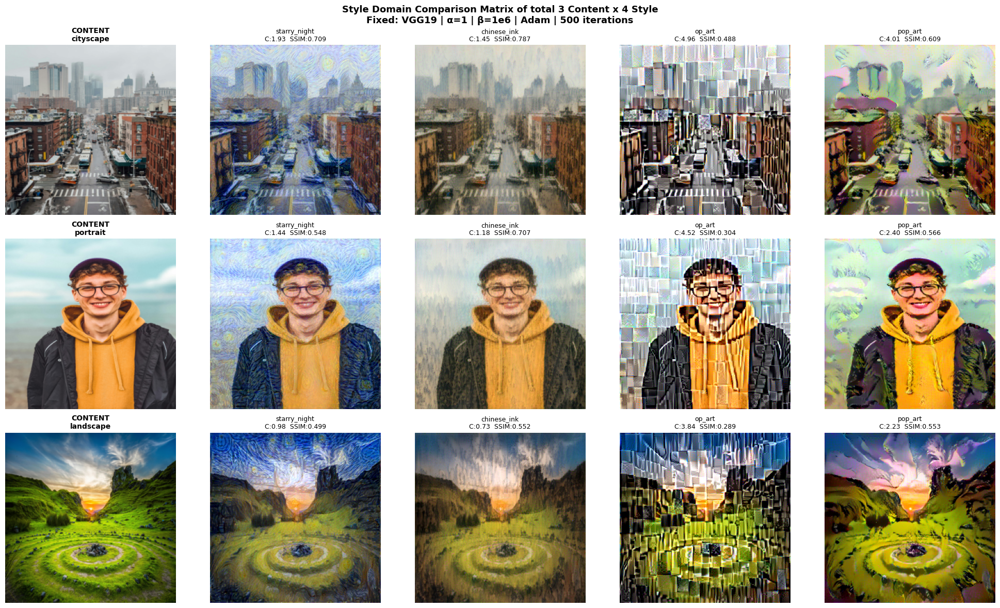

Saved to: /content/NST_Project/outputs/style_domain_matrix.png


In [ ]:
# Visual matrix: rows = content, columns = style
n_content = len(content_tensors)
n_style   = len(style_tensors)

fig, axes = plt.subplots(n_content, n_style + 1,
                         figsize=(4 * (n_style + 1), 4 * n_content))

content_order = list(content_tensors.keys())
style_order   = list(style_tensors.keys())

for row, c_name in enumerate(content_order):
    # First column: the original content image for reference
    axes[row][0].imshow(tensor_to_image(content_tensors[c_name]))
    axes[row][0].set_title(f"CONTENT\n{c_name}", fontsize=10, fontweight='bold')
    axes[row][0].axis('off')

    # Remaining columns: each stylised output
    for col, s_name in enumerate(style_order, start=1):
        r = next(x for x in matrix_results
                 if x['content_name'] == c_name and x['style_name'] == s_name)
        img_path = os.path.join(
            OUTPUT_DIR, f"{r['label']}_iter{MATRIX_ITERATIONS:04d}.png"
        )
        axes[row][col].imshow(plt.imread(img_path))
        axes[row][col].set_title(
            f"{s_name}\nC:{r['history']['content'][-1]:.2f}  "
            f"SSIM:{r['ssim']:.3f}",
            fontsize=9
        )
        axes[row][col].axis('off')

plt.suptitle(
    'Style Domain Comparison Matrix of total 3 Content x 4 Style\n'
    'Fixed: VGG19 | α=1 | β=1e6 | Adam | 500 iterations',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()

matrix_path = os.path.join(OUTPUT_DIR, 'style_domain_matrix.png')
plt.savefig(matrix_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to: {matrix_path}")

In [ ]:
#Matrix results table
print("  Style Domain Comparison")
print("-" * 74)
print("  Fixed: VGG19 | α=1 | β=1e6 | Adam lr=0.01 | 500 iters | seed=42")
print("-" * 74)
print(f"  {'Content':<12} {'Style':<14} {'Final C-loss':>14} "
      f"{'Final S-loss':>14} {'SSIM':>8} {'Runtime':>9}")
print("-" * 74)
for r in matrix_results:
    h = r['history']
    print(f"  {r['content_name']:<12} {r['style_name']:<14} "
          f"{h['content'][-1]:>14.4f} "
          f"{h['style'][-1]:>14.6f} "
          f"{r['ssim']:>8.4f} "
          f"{r['runtime']:>8.1f}s")

# Group observations by content type
print("\nSSIM grouped by content type (higher = more structure retained):")
print("-" * 74)
for c_name in content_tensors:
    scores = [r['ssim'] for r in matrix_results if r['content_name'] == c_name]
    print(f"  {c_name:<12}: {' | '.join(f'{s:.4f}' for s in scores)} "
          f"(mean {sum(scores)/len(scores):.4f})")

  Style Domain Comparison
--------------------------------------------------------------------------
  Fixed: VGG19 | α=1 | β=1e6 | Adam lr=0.01 | 500 iters | seed=42
--------------------------------------------------------------------------
  Content      Style            Final C-loss   Final S-loss     SSIM   Runtime
--------------------------------------------------------------------------
  cityscape    starry_night           1.9294       0.000003   0.7086     12.6s
  cityscape    chinese_ink            1.4546       0.000002   0.7866     12.6s
  cityscape    op_art                 4.9649       0.000614   0.4880     12.6s
  cityscape    pop_art                4.0096       0.000030   0.6087     12.6s
  portrait     starry_night           1.4442       0.000004   0.5478     12.6s
  portrait     chinese_ink            1.1769       0.000002   0.7067     12.6s
  portrait     op_art                 4.5170       0.000779   0.3045     12.5s
  portrait     pop_art                2.3951       

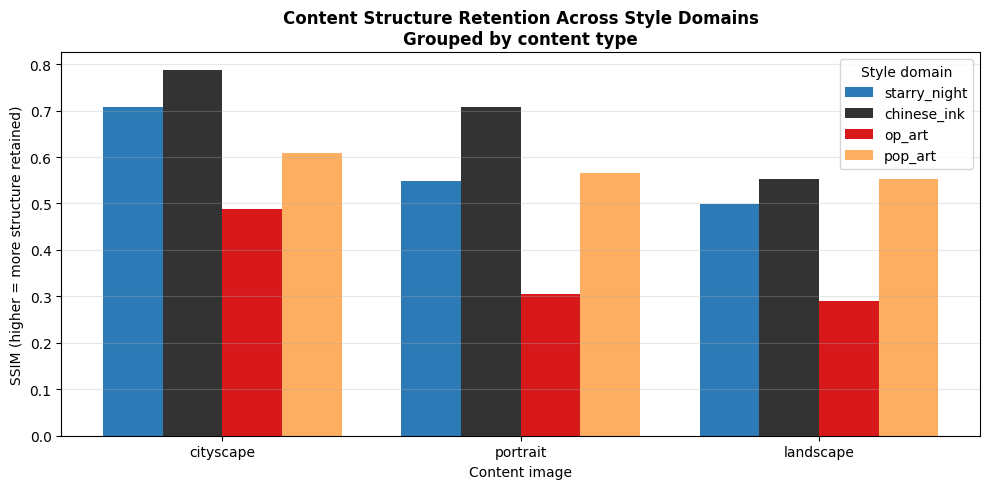

Saved to: /content/NST_Project/outputs/style_domain_ssim_bars.png


In [ ]:
# SSIM comparison across the matrix
content_order = list(content_tensors.keys())
style_order   = list(style_tensors.keys())

x = np.arange(len(content_order))
width = 0.20
style_colours = {
    'starry_night': '#2c7bb6',
    'chinese_ink':  '#333333',
    'op_art':       '#d7191c',
    'pop_art':      '#fdae61',
}

fig, ax = plt.subplots(figsize=(10, 5))

for i, s_name in enumerate(style_order):
    scores = []
    for c_name in content_order:
        r = next(x_ for x_ in matrix_results
                 if x_['content_name'] == c_name and x_['style_name'] == s_name)
        scores.append(r['ssim'])
    ax.bar(x + i * width, scores, width,
           label=s_name, color=style_colours.get(s_name, None))

ax.set_xlabel('Content image')
ax.set_ylabel('SSIM (higher = more structure retained)')
ax.set_title('Content Structure Retention Across Style Domains\n'
             'Grouped by content type', fontsize=12, fontweight='bold')
# Centre the tick under the middle of each 4-bar group
ax.set_xticks(x + width * (len(style_order) - 1) / 2)
ax.set_xticklabels(content_order)
ax.legend(title='Style domain')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
bar_path = os.path.join(OUTPUT_DIR, 'style_domain_ssim_bars.png')
plt.savefig(bar_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to: {bar_path}")

## Section 11: Optimiser Comparison: Adam vs L-BFGS

In [ ]:
def run_nst_lbfgs(alpha, beta, label, content_tensor, style_tensor,
                   vgg, content_target, style_grams,
                   content_idx, style_idx, all_idx,
                   num_iterations=500, log_every=50,
                   output_dir=OUTPUT_DIR, seed=SEED):

    torch.manual_seed(seed)

    # start from a copy of the content image, and optimise the pixels rather than any model weights.
    generated = content_tensor.clone().requires_grad_(True)

    optimizer = optim.LBFGS([generated], max_iter=1, line_search_fn=None)

    history = {'total': [], 'content': [], 'style': []}
    content_layer_index = content_idx[0]

    print(f"\n Run: {label}")
    print(f"   optimiser=L-BFGS  α={alpha} | β={beta:.0e} | {num_iterations} iters")

    start = time.time()

    def closure():
        optimizer.zero_grad()

        gen_features = get_features(generated, vgg, all_idx)

        c_loss = content_loss(
            gen_features[content_layer_index], content_target
        )
        s_loss = style_loss(gen_features, style_grams, style_idx)

        total = alpha * c_loss + beta * s_loss
        total.backward()

        closure.c_loss = c_loss.item()
        closure.s_loss = s_loss.item()
        closure.total_loss = total.item()

        return total

    for iteration in range(1, num_iterations + 1):
        # optimizer.step(closure) calls closure() once, gets the loss and gradient at the current pixels, and updates them using L-BFGS's estimated descent direction.
        optimizer.step(closure)

        history['content'].append(closure.c_loss)
        history['style'].append(closure.s_loss)
        history['total'].append(closure.total_loss)

        if iteration % log_every == 0 or iteration == 1:
            print(f"   iter {iteration:>4} | "
                  f"content: {closure.c_loss:.4f} | "
                  f"style: {closure.s_loss:.6f} | "
                  f"total: {closure.total_loss:.4f}")

    runtime = time.time() - start

    output_path = os.path.join(output_dir, f'{label}_iter{num_iterations:04d}.png')
    plt.imsave(output_path, tensor_to_image(generated))

    print(f"   Completed in {runtime:.1f}s | saved to {output_path}")

    return {
        'label'     : label,
        'alpha'     : alpha,
        'beta'      : beta,
        'optimiser' : 'L-BFGS',
        'generated' : generated,
        'history'   : history,
        'runtime'   : runtime,
    }

In [ ]:
# Controlled optimiser comparison
# Both runs use identical hyperparameters (α, β), the same content and style images, the same VGG19 feature extractor and precomputed targets, and the same random seed.
# Adam is re-run here rather than reusing an earlier result so that both optimisers execute in the same session under identical GPU warm-up conditions.

OPT_ALPHA      = 1.0
OPT_BETA       = 1e6
OPT_ITERATIONS = 500
OPT_LOG_EVERY  = 50

print("Optimiser comparison with fixed configuration:")
print(f"  α={OPT_ALPHA} | β={OPT_BETA:.0e} | {OPT_ITERATIONS} iterations | seed={SEED}")

optimiser_results = []

# Run 1: Adam
result_adam = run_nst(
    alpha          = OPT_ALPHA,
    beta           = OPT_BETA,
    label          = 'Opt_Adam',
    content_tensor = content_tensor,
    style_tensor   = style_tensor,
    vgg            = vgg,
    content_target = content_target,
    style_grams    = style_grams,
    content_idx    = content_idx,
    style_idx      = style_idx,
    all_idx        = all_idx,
    lr             = 0.01,
    num_iterations = OPT_ITERATIONS,
    log_every      = OPT_LOG_EVERY,
)
result_adam['optimiser'] = 'Adam'
optimiser_results.append(result_adam)

# Run 2: L-BFGS
result_lbfgs = run_nst_lbfgs(
    alpha          = OPT_ALPHA,
    beta           = OPT_BETA,
    label          = 'Opt_LBFGS',
    content_tensor = content_tensor,
    style_tensor   = style_tensor,
    vgg            = vgg,
    content_target = content_target,
    style_grams    = style_grams,
    content_idx    = content_idx,
    style_idx      = style_idx,
    all_idx        = all_idx,
    num_iterations = OPT_ITERATIONS,
    log_every      = OPT_LOG_EVERY,
)
optimiser_results.append(result_lbfgs)

print("\nBoth optimiser runs complete.")

Optimiser comparison with fixed configuration:
  α=1.0 | β=1e+06 | 500 iterations | seed=42

 RUN: Opt_Adam
   α=1.0 | β=1e+06 | lr=0.01 | 500 iters
   iter    1 | content: 0.0000 | style: 0.000188 | total: 188.0868
   iter   50 | content: 2.9305 | style: 0.000017 | total: 19.7326
   iter  100 | content: 2.5506 | style: 0.000011 | total: 13.3229
   iter  150 | content: 2.3434 | style: 0.000008 | total: 10.7670
   iter  200 | content: 2.2059 | style: 0.000007 | total: 9.2174
   iter  250 | content: 2.1266 | style: 0.000006 | total: 8.1364
   iter  300 | content: 2.0689 | style: 0.000005 | total: 7.3193
   iter  350 | content: 2.0230 | style: 0.000005 | total: 6.6673
   iter  400 | content: 1.9822 | style: 0.000004 | total: 6.1308
   iter  450 | content: 1.9492 | style: 0.000004 | total: 5.6913
   iter  500 | content: 1.9219 | style: 0.000003 | total: 5.3339
   Completed in 12.5s | saved to /content/NST_Project/outputs/Opt_Adam_iter0500.png

 Run: Opt_LBFGS
   optimiser=L-BFGS  α=1.0 | β

In [ ]:
# Compute SSIM and assemble the comparison table
for r in optimiser_results:
    r['ssim'] = compute_ssim(content_tensor, r['generated'])

print("  Optimiser Comparison of Adam vs L-BFGS")
print("  Fixed: α=1 | β=1e6 | VGG19 | 500 iters | 256×256 | seed=42")
print("-" * 88)
print(f"  {'Optimiser':<12} {'Final C-loss':>14} {'Final S-loss':>14} "
      f"{'SSIM':>8} {'Runtime':>10}")
print("-" * 88)

for r in optimiser_results:
    h = r['history']
    print(f"  {r['optimiser']:<12} "
          f"{h['content'][-1]:>14.4f} "
          f"{h['style'][-1]:>14.6f} "
          f"{r['ssim']:>8.4f} "
          f"{r['runtime']:>9.1f}s")

adam_r, lbfgs_r = optimiser_results[0], optimiser_results[1]
c_diff    = ((lbfgs_r['history']['content'][-1] - adam_r['history']['content'][-1])
             / adam_r['history']['content'][-1] * 100)
s_diff    = ((lbfgs_r['history']['style'][-1] - adam_r['history']['style'][-1])
             / adam_r['history']['style'][-1] * 100)
ssim_diff = lbfgs_r['ssim'] - adam_r['ssim']
time_diff = ((lbfgs_r['runtime'] - adam_r['runtime']) / adam_r['runtime'] * 100)

print("\n  L-BFGS relative to Adam baseline:")
print(f"    Content loss : {c_diff:+.1f}%")
print(f"    Style loss   : {s_diff:+.1f}%")
print(f"    SSIM         : {ssim_diff:+.4f} (absolute difference)")
print(f"    Runtime      : {time_diff:+.1f}%")

  Optimiser Comparison of Adam vs L-BFGS
  Fixed: α=1 | β=1e6 | VGG19 | 500 iters | 256×256 | seed=42
----------------------------------------------------------------------------------------
  Optimiser      Final C-loss   Final S-loss     SSIM    Runtime
----------------------------------------------------------------------------------------
  Adam                 1.9219       0.000003   0.7086      12.5s
  L-BFGS               1.5596       0.000001   0.4256      17.0s

  L-BFGS relative to Adam baseline:
    Content loss : -18.9%
    Style loss   : -60.7%
    SSIM         : -0.2831 (absolute difference)
    Runtime      : +36.4%


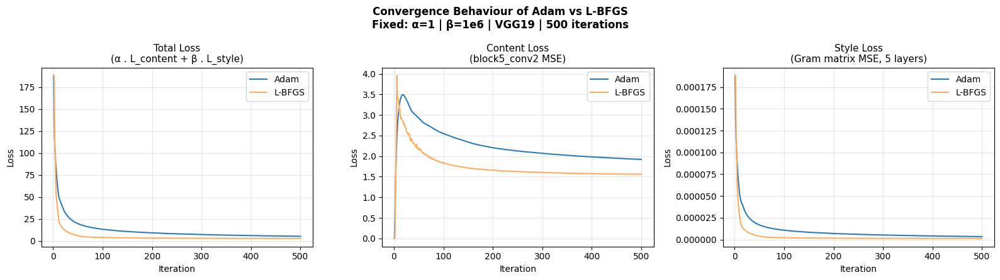

Saved to: /content/NST_Project/outputs/optimiser_loss_curves.png


In [ ]:
# Convergence comparison
iters = list(range(1, OPT_ITERATIONS + 1))
opt_colours = {'Adam': '#2c7bb6', 'L-BFGS': '#fdae61'}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for r in optimiser_results:
    c = opt_colours[r['optimiser']]
    lbl = r['optimiser']
    axes[0].plot(iters, r['history']['total'],   color=c, linewidth=1.5, label=lbl)
    axes[1].plot(iters, r['history']['content'], color=c, linewidth=1.5, label=lbl)
    axes[2].plot(iters, r['history']['style'],   color=c, linewidth=1.5, label=lbl)

titles = [
    'Total Loss\n(α . L_content + β . L_style)',
    'Content Loss\n(block5_conv2 MSE)',
    'Style Loss\n(Gram matrix MSE, 5 layers)',
]
for ax, t in zip(axes, titles):
    ax.set_title(t, fontsize=11)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle(
    'Convergence Behaviour of Adam vs L-BFGS\n'
    'Fixed: α=1 | β=1e6 | VGG19 | 500 iterations',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()

optimiser_curves_path = os.path.join(OUTPUT_DIR, 'optimiser_loss_curves.png')
plt.savefig(optimiser_curves_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to: {optimiser_curves_path}")

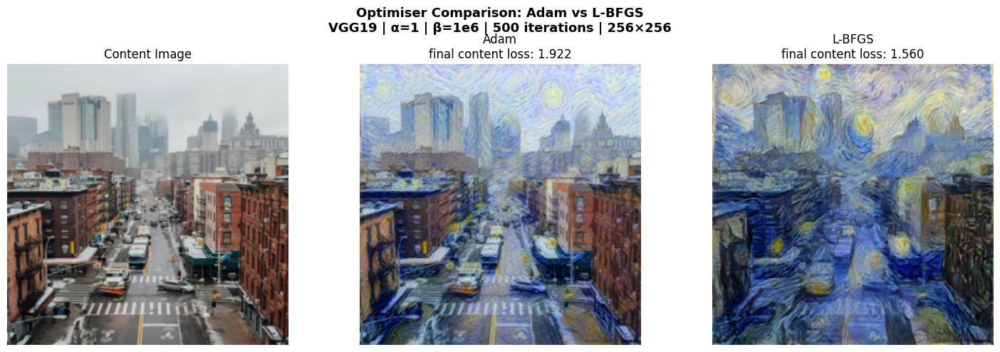

Comparison figure saved to: /content/NST_Project/outputs/optimiser_comparison.png


In [ ]:
# Visual comparison: content, Adam output, L-BFGS output
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(tensor_to_image(content_tensor))
axes[0].set_title('Content Image', fontsize=12)
axes[0].axis('off')

axes[1].imshow(tensor_to_image(adam_r['generated']))
axes[1].set_title(f"Adam\nfinal content loss: {adam_r['history']['content'][-1]:.3f}",
                   fontsize=12)
axes[1].axis('off')

axes[2].imshow(tensor_to_image(lbfgs_r['generated']))
axes[2].set_title(f"L-BFGS\nfinal content loss: {lbfgs_r['history']['content'][-1]:.3f}",
                   fontsize=12)
axes[2].axis('off')

plt.suptitle(
    'Optimiser Comparison: Adam vs L-BFGS\n'
    'VGG19 | α=1 | β=1e6 | 500 iterations | 256×256',
    fontsize=13,
    fontweight='bold'
)
plt.tight_layout()

optimiser_comparison_path = os.path.join(OUTPUT_DIR, 'optimiser_comparison.png')
plt.savefig(optimiser_comparison_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Comparison figure saved to: {optimiser_comparison_path}")

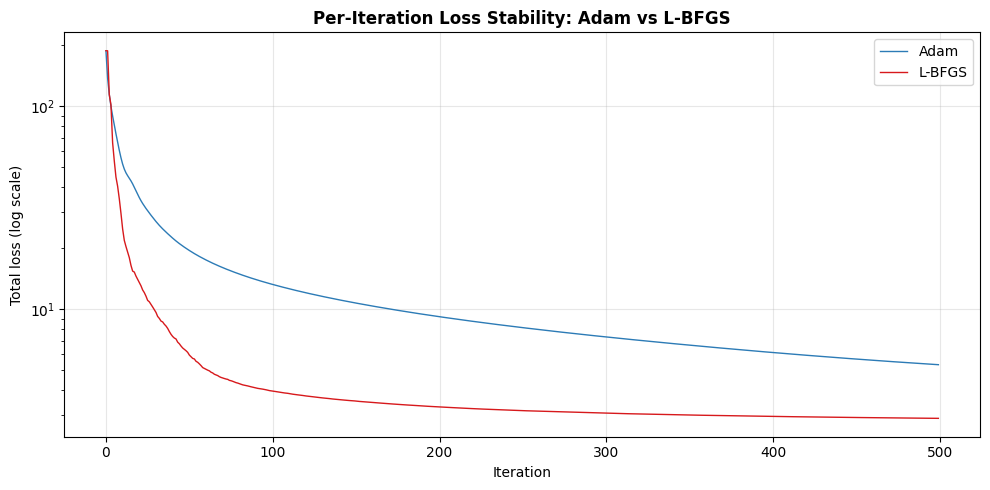

Saved to: /content/NST_Project/outputs/optimiser_stability.png


In [ ]:
# Per-iteration loss stability: does L-BFGS's faster convergence come with instability?
opt_adam  = next(r for r in optimiser_results if r['optimiser'] == 'Adam')
opt_lbfgs = next(r for r in optimiser_results if r['optimiser'] == 'L-BFGS')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(opt_adam['history']['total'],  label='Adam',   color='#2c7bb6', linewidth=1)
ax.plot(opt_lbfgs['history']['total'], label='L-BFGS', color='#d7191c', linewidth=1)
ax.set_yscale('log')   # log scale exposes oscillation/spikes at small loss values
ax.set_xlabel('Iteration'); ax.set_ylabel('Total loss (log scale)')
ax.set_title('Per-Iteration Loss Stability: Adam vs L-BFGS', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
stab_path = os.path.join(OUTPUT_DIR, 'optimiser_stability.png')
plt.savefig(stab_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to: {stab_path}")

## Section 12: Colour Histogram Divergence

In [ ]:
# Colour histogram divergence measures how closely a generated image's colour palette matches the style image it was optimised toward. It is computed on
# the RGB pixel distributions, independently of the VGG feature space that content and style loss live in, so it adds a genuinely different axis of
# evaluation.

from scipy.spatial.distance import jensenshannon

# Style file lookup
STYLE_PATHS = dict(style_images)

def load_rgb_uint8(path, size=(IMG_SIZE, IMG_SIZE)):
    """
    Load an image from disk for colour analysis.
    """
    img = Image.open(path).convert('RGB').resize(size)
    return np.array(img)

def colour_js_divergence(generated_rgb, style_rgb, bins=256):
    """
    Jensen-Shannon divergence between two images' RGB colour distributions.

    For each colour channel, a 256-bin histogram is built and treated as a probability distribution. The Jensen-Shannon divergence between the
    generated and style histograms is computed per channel, then averaged across the three channels. JS divergence is symmetric and bounded in
    [0, 1] (base 2): 0 means identical colour distributions, 1 means maximally
    different. A low value therefore means the output has adopted the style image's palette closely.
    """
    divergences = []
    for ch in range(3):
        gen_hist, _ = np.histogram(generated_rgb[..., ch], bins=bins, range=(0, 256))
        sty_hist, _ = np.histogram(style_rgb[..., ch],     bins=bins, range=(0, 256))
        distance = jensenshannon(gen_hist, sty_hist, base=2)
        divergences.append(distance ** 2)
    return float(np.mean(divergences))

# Sanity test: an image compared against itself must give 0.0 divergence.
_test_img  = load_rgb_uint8(STYLE_PATHS['starry_night'])
_self_div  = colour_js_divergence(_test_img, _test_img)
print(f"Sanity check (style vs itself): JS divergence = {_self_div:.6f}")

Sanity check (style vs itself): JS divergence = 0.000000


In [ ]:
# Apply colour divergence to every saved output across all experiments.
# Each generated image is compared against the style image it was optimised toward. Entries are gathered from the in-memory result lists so each number
# stays tied to its experiment

colour_entries = []   # (experiment, label, generated_png_name, style_key)

# Experiment 2: β-sweep (all use starry_night)
for r in results:
    colour_entries.append(('Hyperparameter', r['label'],
                           f"{r['label']}_iter{FIXED_ITERATIONS:04d}.png", 'starry_night'))

# Experiment 3: architecture comparison (starry_night)
for r in arch_results:
    colour_entries.append(('Architecture', r['label'],
                           f"{r['label']}_iter{ARCH_ITERATIONS:04d}.png", 'starry_night'))

# Experiment 4: style matrix (each cell has its own style)
for r in matrix_results:
    colour_entries.append(('Style matrix', r['label'],
                           f"{r['label']}_iter{MATRIX_ITERATIONS:04d}.png", r['style_name']))

# Experiment 5: optimiser comparison (starry_night)
for r in optimiser_results:
    colour_entries.append(('Optimiser', r['label'],
                           f"{r['label']}_iter{OPT_ITERATIONS:04d}.png", 'starry_night'))

colour_results = []
for experiment, label, png_name, style_key in colour_entries:
    gen_path = os.path.join(OUTPUT_DIR, png_name)
    if not os.path.exists(gen_path):
        print(f"  [skip] missing file: {png_name}")
        continue
    gen_rgb = load_rgb_uint8(gen_path)
    sty_rgb = load_rgb_uint8(STYLE_PATHS[style_key])
    colour_results.append({
        'experiment': experiment,
        'label':      label,
        'style':      style_key,
        'colour_js':  colour_js_divergence(gen_rgb, sty_rgb),
    })

print("  Colour Histogram Divergence (RGB, Jensen-Shannon)")
print("  if lower = generated palette closer to the style image's palette")
print("-" * 76)
print(f"  {'Experiment':<16} {'Run':<26} {'Style':<14} {'JS div':>8}")
print("-" * 76)
for r in colour_results:
    print(f"  {r['experiment']:<16} {r['label']:<26} {r['style']:<14} {r['colour_js']:>8.4f}")

  Colour Histogram Divergence (RGB, Jensen-Shannon)
  if lower = generated palette closer to the style image's palette
----------------------------------------------------------------------------
  Experiment       Run                        Style            JS div
----------------------------------------------------------------------------
  Hyperparameter   Run_B_low_style            starry_night     0.1626
  Hyperparameter   Run_baseline               starry_night     0.1639
  Hyperparameter   Run_A_high_style           starry_night     0.1643
  Architecture     Arch_VGG19                 starry_night     0.1639
  Architecture     Arch_VGG16                 starry_night     0.1601
  Style matrix     cityscape__starry_night    starry_night     0.1639
  Style matrix     cityscape__chinese_ink     chinese_ink      0.2568
  Style matrix     cityscape__op_art          op_art           0.4180
  Style matrix     cityscape__pop_art         pop_art          0.2982
  Style matrix     portrait

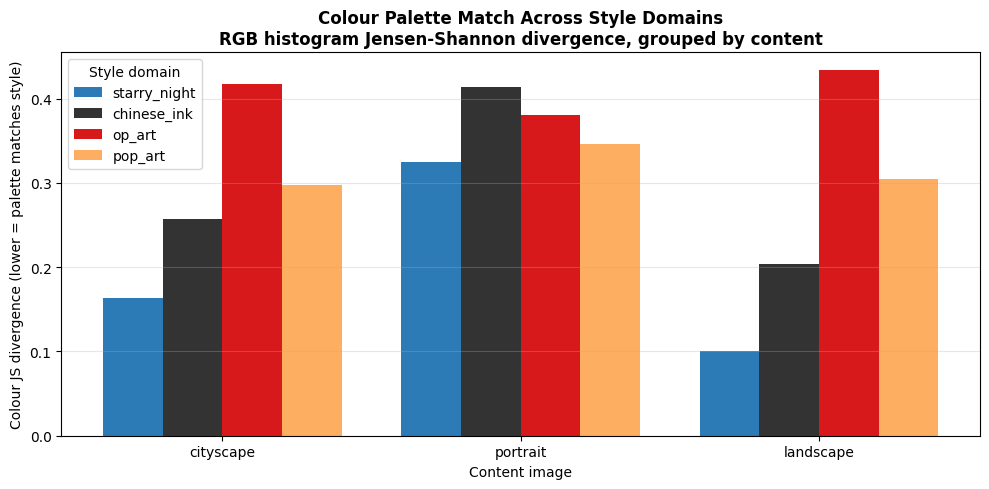

Saved to: /content/NST_Project/outputs/colour_js_divergence_bars.png


In [ ]:
# Colour divergence across the style matrix, grouped by content
matrix_colour = [r for r in colour_results if r['experiment'] == 'Style matrix']

x = np.arange(len(content_order))
width = 0.20
fig, ax = plt.subplots(figsize=(10, 5))

for i, s_name in enumerate(style_order):
    scores = []
    for c_name in content_order:
        entry = next(e for e in matrix_colour if e['label'] == f"{c_name}__{s_name}")
        scores.append(entry['colour_js'])
    ax.bar(x + i * width, scores, width, label=s_name,
           color=style_colours.get(s_name, None))

ax.set_xlabel('Content image')
ax.set_ylabel('Colour JS divergence (lower = palette matches style)')
ax.set_title('Colour Palette Match Across Style Domains\n'
             'RGB histogram Jensen-Shannon divergence, grouped by content',
             fontsize=12, fontweight='bold')
ax.set_xticks(x + width * (len(style_order) - 1) / 2)
ax.set_xticklabels(content_order)
ax.legend(title='Style domain')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
colour_bar_path = os.path.join(OUTPUT_DIR, 'colour_js_divergence_bars.png')
plt.savefig(colour_bar_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to: {colour_bar_path}")

## Section 13: Convergence Rate

In [ ]:
# The loss curves already show convergence visually, but plateau needs an operational definition to be
# reported rather than eyeballed, so it is defined here as the first iteration at which total loss comes within a fixed fraction of its final value.

def convergence_iteration(total_history, threshold=0.05):
    """
    Find the iteration at which total loss first reaches its plateau.
    """
    final = total_history[-1]
    band  = abs(final) * threshold
    for i, value in enumerate(total_history, start=1):
        if abs(value - final) <= band:
            return i
    return len(total_history)

# Apply to every logged run across experiments
convergence_entries = []
for r in results:
    convergence_entries.append(('Hyperparameter', r['label'], r['history']['total']))
for r in arch_results:
    convergence_entries.append(('Architecture', r['label'], r['history']['total']))
for r in optimiser_results:
    convergence_entries.append(('Optimiser', r['label'], r['history']['total']))
for r in matrix_results:
    convergence_entries.append(('Style matrix', r['label'], r['history']['total']))
for r in iter_results:
    convergence_entries.append(('Iteration budget', r['label'], r['history']['total']))
for r in multi_arch_results:
    convergence_entries.append(('Architecture(multi)', r['label'], r['history']['total']))

print("  Convergence Rate (iteration at which total loss plateaus)")
print("  Plateau = first iteration within 5% and within 1% of the final total loss")
print("-" * 80)
print(f"  {'Experiment':<16} {'Run':<26} {'Iter 5%':>8} {'Iter 1%':>8} {'Final total':>13}")
print("-" * 80)
for experiment, label, total_hist in convergence_entries:
    it5 = convergence_iteration(total_hist, 0.05)
    it1 = convergence_iteration(total_hist, 0.01)
    print(f"  {experiment:<16} {label:<26} {it5:>8} {it1:>8} {total_hist[-1]:>13.4f}")

  Convergence Rate (iteration at which total loss plateaus)
  Plateau = first iteration within 5% and within 1% of the final total loss
--------------------------------------------------------------------------------
  Experiment       Run                         Iter 5%  Iter 1%   Final total
--------------------------------------------------------------------------------
  Hyperparameter   Run_B_low_style                 440      487        1.1206
  Hyperparameter   Run_baseline                    462      492        5.3270
  Hyperparameter   Run_A_high_style                477      496       30.5513
  Architecture     Arch_VGG19                      462      492        5.3342
  Architecture     Arch_VGG16                      460      492        4.8833
  Optimiser        Opt_Adam                        462      492        5.3339
  Optimiser        Opt_LBFGS                       323      449        2.9017
  Style matrix     cityscape__starry_night         462      492        5.3357


## Section 14: Consolidated Analysis

In [ ]:
# Every experiment's key metrics gathered into one table.
import pandas as pd

# SSIM for the iteration-budget runs
for r in iter_results:
    if 'ssim' not in r:
        r['ssim'] = compute_ssim(content_tensor, r['generated'])

# Colour divergence for the iteration-budget and multi-pair runs.
extra_colour_entries = []
for r in iter_results:
    extra_colour_entries.append(('Iteration budget', r['label'],
                                 f"{r['label']}_iter{r['num_iterations']:04d}.png",
                                 'starry_night'))
for r in multi_arch_results:
    extra_colour_entries.append(('Architecture (multi-pair)', r['label'],
                                 f"{r['label']}_iter{ARCH_ITERATIONS:04d}.png",
                                 r['style_name']))

existing_labels = {c['label'] for c in colour_results}
for experiment, label, png_name, style_key in extra_colour_entries:
    if label in existing_labels:
        continue
    gen_path = os.path.join(OUTPUT_DIR, png_name)
    if not os.path.exists(gen_path):
        print(f"  [skip] missing file: {png_name}")
        continue
    colour_results.append({
        'experiment': experiment,
        'label':      label,
        'style':      style_key,
        'colour_js':  colour_js_divergence(load_rgb_uint8(gen_path),
                                           load_rgb_uint8(STYLE_PATHS[style_key])),
    })

# Consolidated master table
colour_by_label = {r['label']: r['colour_js'] for r in colour_results}

def summarise(result_list, experiment):
    """Extract one metrics row per run from a result list."""
    rows = []
    for r in result_list:
        h = r['history']
        rows.append({
            'experiment':    experiment,
            'run':           r['label'],
            'final_content': h['content'][-1],
            'final_style':   h['style'][-1],
            'final_total':   h['total'][-1],
            'ssim':          r.get('ssim'),
            'colour_js':     colour_by_label.get(r['label']),
            'runtime_s':     r.get('runtime'),
        })
    return rows

all_rows = []
all_rows += summarise(results,            'Hyperparameter (β)')
all_rows += summarise(iter_results,       'Iteration budget')
all_rows += summarise(arch_results,       'Architecture')
all_rows += summarise(multi_arch_results, 'Architecture (multi-pair)')
all_rows += summarise(matrix_results,     'Style matrix')
all_rows += summarise(optimiser_results,  'Optimiser')

master_df = pd.DataFrame(all_rows).round(
    {'final_content': 4, 'final_style': 6, 'final_total': 4,
     'ssim': 4, 'colour_js': 4, 'runtime_s': 1})

csv_path = os.path.join(OUTPUT_DIR, 'master_results.csv')
master_df.to_csv(csv_path, index=False)
print(f"Master results table: {len(master_df)} runs -> saved {csv_path}")
master_df

Master results table: 28 runs -> saved /content/NST_Project/outputs/master_results.csv


,experiment,run,final_content,final_style,final_total,ssim,colour_js,runtime_s
0,Hyperparameter (β),Run_B_low_style,0.3610,0.000008,1.1206,0.7105,0.1626,11.5
1,Hyperparameter (β),Run_baseline,1.9144,0.000003,5.3270,0.7085,0.1639,11.5
2,Hyperparameter (β),Run_A_high_style,3.9844,0.000003,30.5513,0.7126,0.1643,11.7
3,Iteration budget,Iter_0500,1.9226,0.000003,5.3298,0.7087,0.1639,11.8
4,Iteration budget,Iter_1000,1.7409,0.000002,3.9553,0.6429,0.1578,23.8
5,Iteration budget,Iter_2000,1.6066,0.000002,3.3739,0.5777,0.1396,48.6
6,Architecture,Arch_VGG19,1.9232,0.000003,5.3342,0.7087,0.1639,12.3
7,Architecture,Arch_VGG16,1.7550,0.000003,4.8833,0.6927,0.1601,10.3
8,Architecture (multi-pair),Arch_portrait__chinese_ink_VGG19,1.1828,0.000002,2.9255,0.7066,0.4142,12.3
9,Architecture (multi-pair),Arch_portrait__chinese_ink_VGG16,1.1987,0.000002,3.1048,0.7031,0.4146,10.4


In [ ]:
# check do the three quantitative metrics agree, or capture different things?
from scipy.stats import spearmanr

matrix_df = master_df[master_df['experiment'] == 'Style matrix'].dropna(
    subset=['final_content', 'ssim', 'colour_js'])

metric_pairs = [('final_content', 'ssim'),
                ('final_content', 'colour_js'),
                ('ssim',          'colour_js')]

print("  Metric agreement: Spearman rank correlation (style-matrix runs, n=12)")
print("-" * 66)
for a, b in metric_pairs:
    rho, p = spearmanr(matrix_df[a], matrix_df[b])
    print(f"  {a:>14} vs {b:<11}  rho = {rho:+.3f}   p = {p:.3f}")
print("-" * 66)

  Metric agreement: Spearman rank correlation (style-matrix runs, n=12)
------------------------------------------------------------------
   final_content vs ssim         rho = -0.329   p = 0.297
   final_content vs colour_js    rho = +0.580   p = 0.048
            ssim vs colour_js    rho = -0.462   p = 0.131
------------------------------------------------------------------


## Section 15: Validation

In [ ]:
# testing: it confirms each building block is implemented correctly before results are trusted
import torch

checks = []
_f = torch.randn(1, 8, 16, 16, device=device)
checks.append(('Gram matrix is symmetric',
               torch.allclose(gram_matrix(_f), gram_matrix(_f).T, atol=1e-4)))
checks.append(('Content loss == 0 for identical input',
               content_loss(_f, _f).item() < 1e-6))
checks.append(('SSIM == 1.0 for identical image',
               abs(compute_ssim(content_tensor, content_tensor) - 1.0) < 1e-6))
_rgb = load_rgb_uint8(STYLE_PATHS['starry_night'])
checks.append(('Colour JS == 0.0 for identical image',
               colour_js_divergence(_rgb, _rgb) < 1e-6))
checks.append(('Baseline output has no NaN/Inf',
               torch.isfinite(results[0]['generated']).all().item()))

print("  Pipeline Validation")
print("-" * 48)
for name, passed in checks:
    print(f"  [{'PASS' if passed else 'FAIL'}]  {name}")
assert all(p for _, p in checks), "A validation check failed need to investigate."
print("\n  All validation checks passed.")

  Pipeline Validation
------------------------------------------------
  [PASS]  Gram matrix is symmetric
  [PASS]  Content loss == 0 for identical input
  [PASS]  SSIM == 1.0 for identical image
  [PASS]  Colour JS == 0.0 for identical image
  [PASS]  Baseline output has no NaN/Inf

  All validation checks passed.


## Appendix

In [ ]:
# Environment capture for reproducibility.
import sys, torch, torchvision, numpy, scipy, skimage, PIL, matplotlib
for name, mod in [('Python', sys), ('torch', torch), ('torchvision', torchvision),
                  ('numpy', numpy), ('scipy', scipy), ('scikit-image', skimage),
                  ('Pillow', PIL), ('matplotlib', matplotlib)]:
    v = sys.version.split()[0] if name == 'Python' else mod.__version__
    print(f"  {name:<13} {v}")
print(f"  CUDA          {torch.version.cuda} | "
      f"{torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

  Python        3.13.15
  torch         2.11.0+cu128
  torchvision   0.26.0+cu128
  numpy         2.1.3
  scipy         1.16.3
  scikit-image  0.25.2
  Pillow        11.3.0
  matplotlib    3.10.0
  CUDA          12.8 | Tesla T4
